# Visualize All Runs for a Given Configuration

This notebook allows you to visualize all 30 runs for a specific parameter configuration (strategy set, N, K, mu) in a 5x6 grid layout.

This helps you:
- Understand equilibrium diversity visually
- Verify if equilibrium classification is accurate
- Compare price trajectories across different runs

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json

# Add project root to sys.path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Setup Plotting Style
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (20, 16)

## Helper Functions

In [3]:
def find_experiment_dir(strats, mu, k):
    """
    Find the experiment directory matching the given parameters.
    
    Parameters:
    -----------
    strats : int
        Number of strategies (3 or 4)
    mu : float
        Learning rate parameter
    k : int
        K parameter
    
    Returns:
    --------
    Path or None
        The experiment directory path if found, None otherwise
    """
    results_dir = project_root / "data" / "results"
    
    # Construct the expected directory name pattern
    # Use anchored substrings to avoid partial matches:
    #   "_mu{mu}_"  prevents "mu0.1" matching "mu0.19"
    #   endswith("_k{k}") prevents "k3" matching "k30" or "k300"
    strat_str = f"{strats}strats"
    mu_str = f"_mu{mu}_"       # mu is always between two underscores
    k_suffix = f"_k{k}"        # k is always at the end of the dir name
    
    # Search for matching directory
    for exp_dir in results_dir.iterdir():
        if not exp_dir.is_dir():
            continue
        
        dir_name = exp_dir.name
        if (strat_str in dir_name
                and mu_str in dir_name
                and dir_name.endswith(k_suffix)):
            return exp_dir
    
    return None


def load_all_runs(strats, N, k, mu):
    """
    Load all parquet files for a given configuration.
    
    Parameters:
    -----------
    strats : int
        Number of strategies (3 or 4)
    N : int
        Number of sellers
    k : int
        K parameter
    mu : float
        Learning rate parameter
    
    Returns:
    --------
    list of tuples
        List of (run_id, DataFrame) tuples
    """
    exp_dir = find_experiment_dir(strats, mu, k)
    
    if exp_dir is None:
        print(f"No experiment found for: {strats}strats, mu={mu}, k={k}")
        return []
    
    n_dir = exp_dir / f"N_{N}"
    
    if not n_dir.exists():
        print(f"No N_{N} directory found in {exp_dir.name}")
        return []
    
    # Load all parquet files
    parquet_files = sorted([p for p in n_dir.glob("run_*.parquet") if "_qtable" not in p.name])
    
    if not parquet_files:
        print(f"No parquet files found in {n_dir}")
        return []
    
    print(f"Found {len(parquet_files)} runs in {exp_dir.name}/N_{N}")
    
    runs = []
    for pf in parquet_files:
        # Extract run number from filename (e.g., run_0.parquet -> 0)
        run_id = int(pf.stem.split('_')[1])
        df = pd.read_parquet(pf)
        runs.append((run_id, df))
    
    # Sort by run_id
    runs.sort(key=lambda x: x[0])
    
    return runs


## Main Visualization Function

In [4]:
def plot_all_runs_grid(strats, N, k, mu, max_steps=200, figsize=(24, 20)):
    """
    Plot all runs for a given configuration in a 5x6 grid.
    
    Parameters:
    -----------
    strats : int
        Number of strategies (3 or 4)
    N : int
        Number of sellers
    k : int
        K parameter
    mu : float
        Learning rate parameter
    max_steps : int, optional
        Maximum number of steps to display (default: 200)
    figsize : tuple, optional
        Figure size (default: (24, 20))
    """
    # Load all runs
    runs = load_all_runs(strats, N, k, mu)
    
    if not runs:
        print("No data to plot.")
        return
    
    # Create 5x6 grid
    fig, axes = plt.subplots(6, 6, figsize=figsize)
    axes = axes.flatten()
    
    # Plot each run
    for idx, (run_id, df) in enumerate(runs):
        if idx >= 36:  # Only plot first 36 runs
            break
        
        ax = axes[idx]
        
        # Slice data to max_steps
        plot_data = df.iloc[:max_steps]
        
        # Find all price columns (p_0, p_1, ...)
        p_cols = sorted([c for c in plot_data.columns if c.startswith('p_')])
        
        # Plot each seller's price
        for col in p_cols:
            ax.plot(plot_data['t_global'], plot_data[col], 
                   linewidth=1.5, alpha=0.7)
        
        ax.set_title(f"Run {run_id}", fontsize=10, fontweight='bold')
        ax.set_xlabel("Time Step", fontsize=8)
        ax.set_ylabel("Price", fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=8)
    
    # Hide unused subplots if less than 30 runs
    for idx in range(len(runs), 30):
        axes[idx].axis('off')
    
    # Overall title
    fig.suptitle(
        f"All Runs: {strats} Strategies | N={N} Sellers | K={k} | mu={mu}\n"
        f"(Showing first {max_steps} steps per run)",
        fontsize=16, fontweight='bold', y=0.995
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()


## Examples

Use the function below to visualize all runs for specific configurations.

Found 100 runs in scan_3strats_mu0.25_k30/N_2


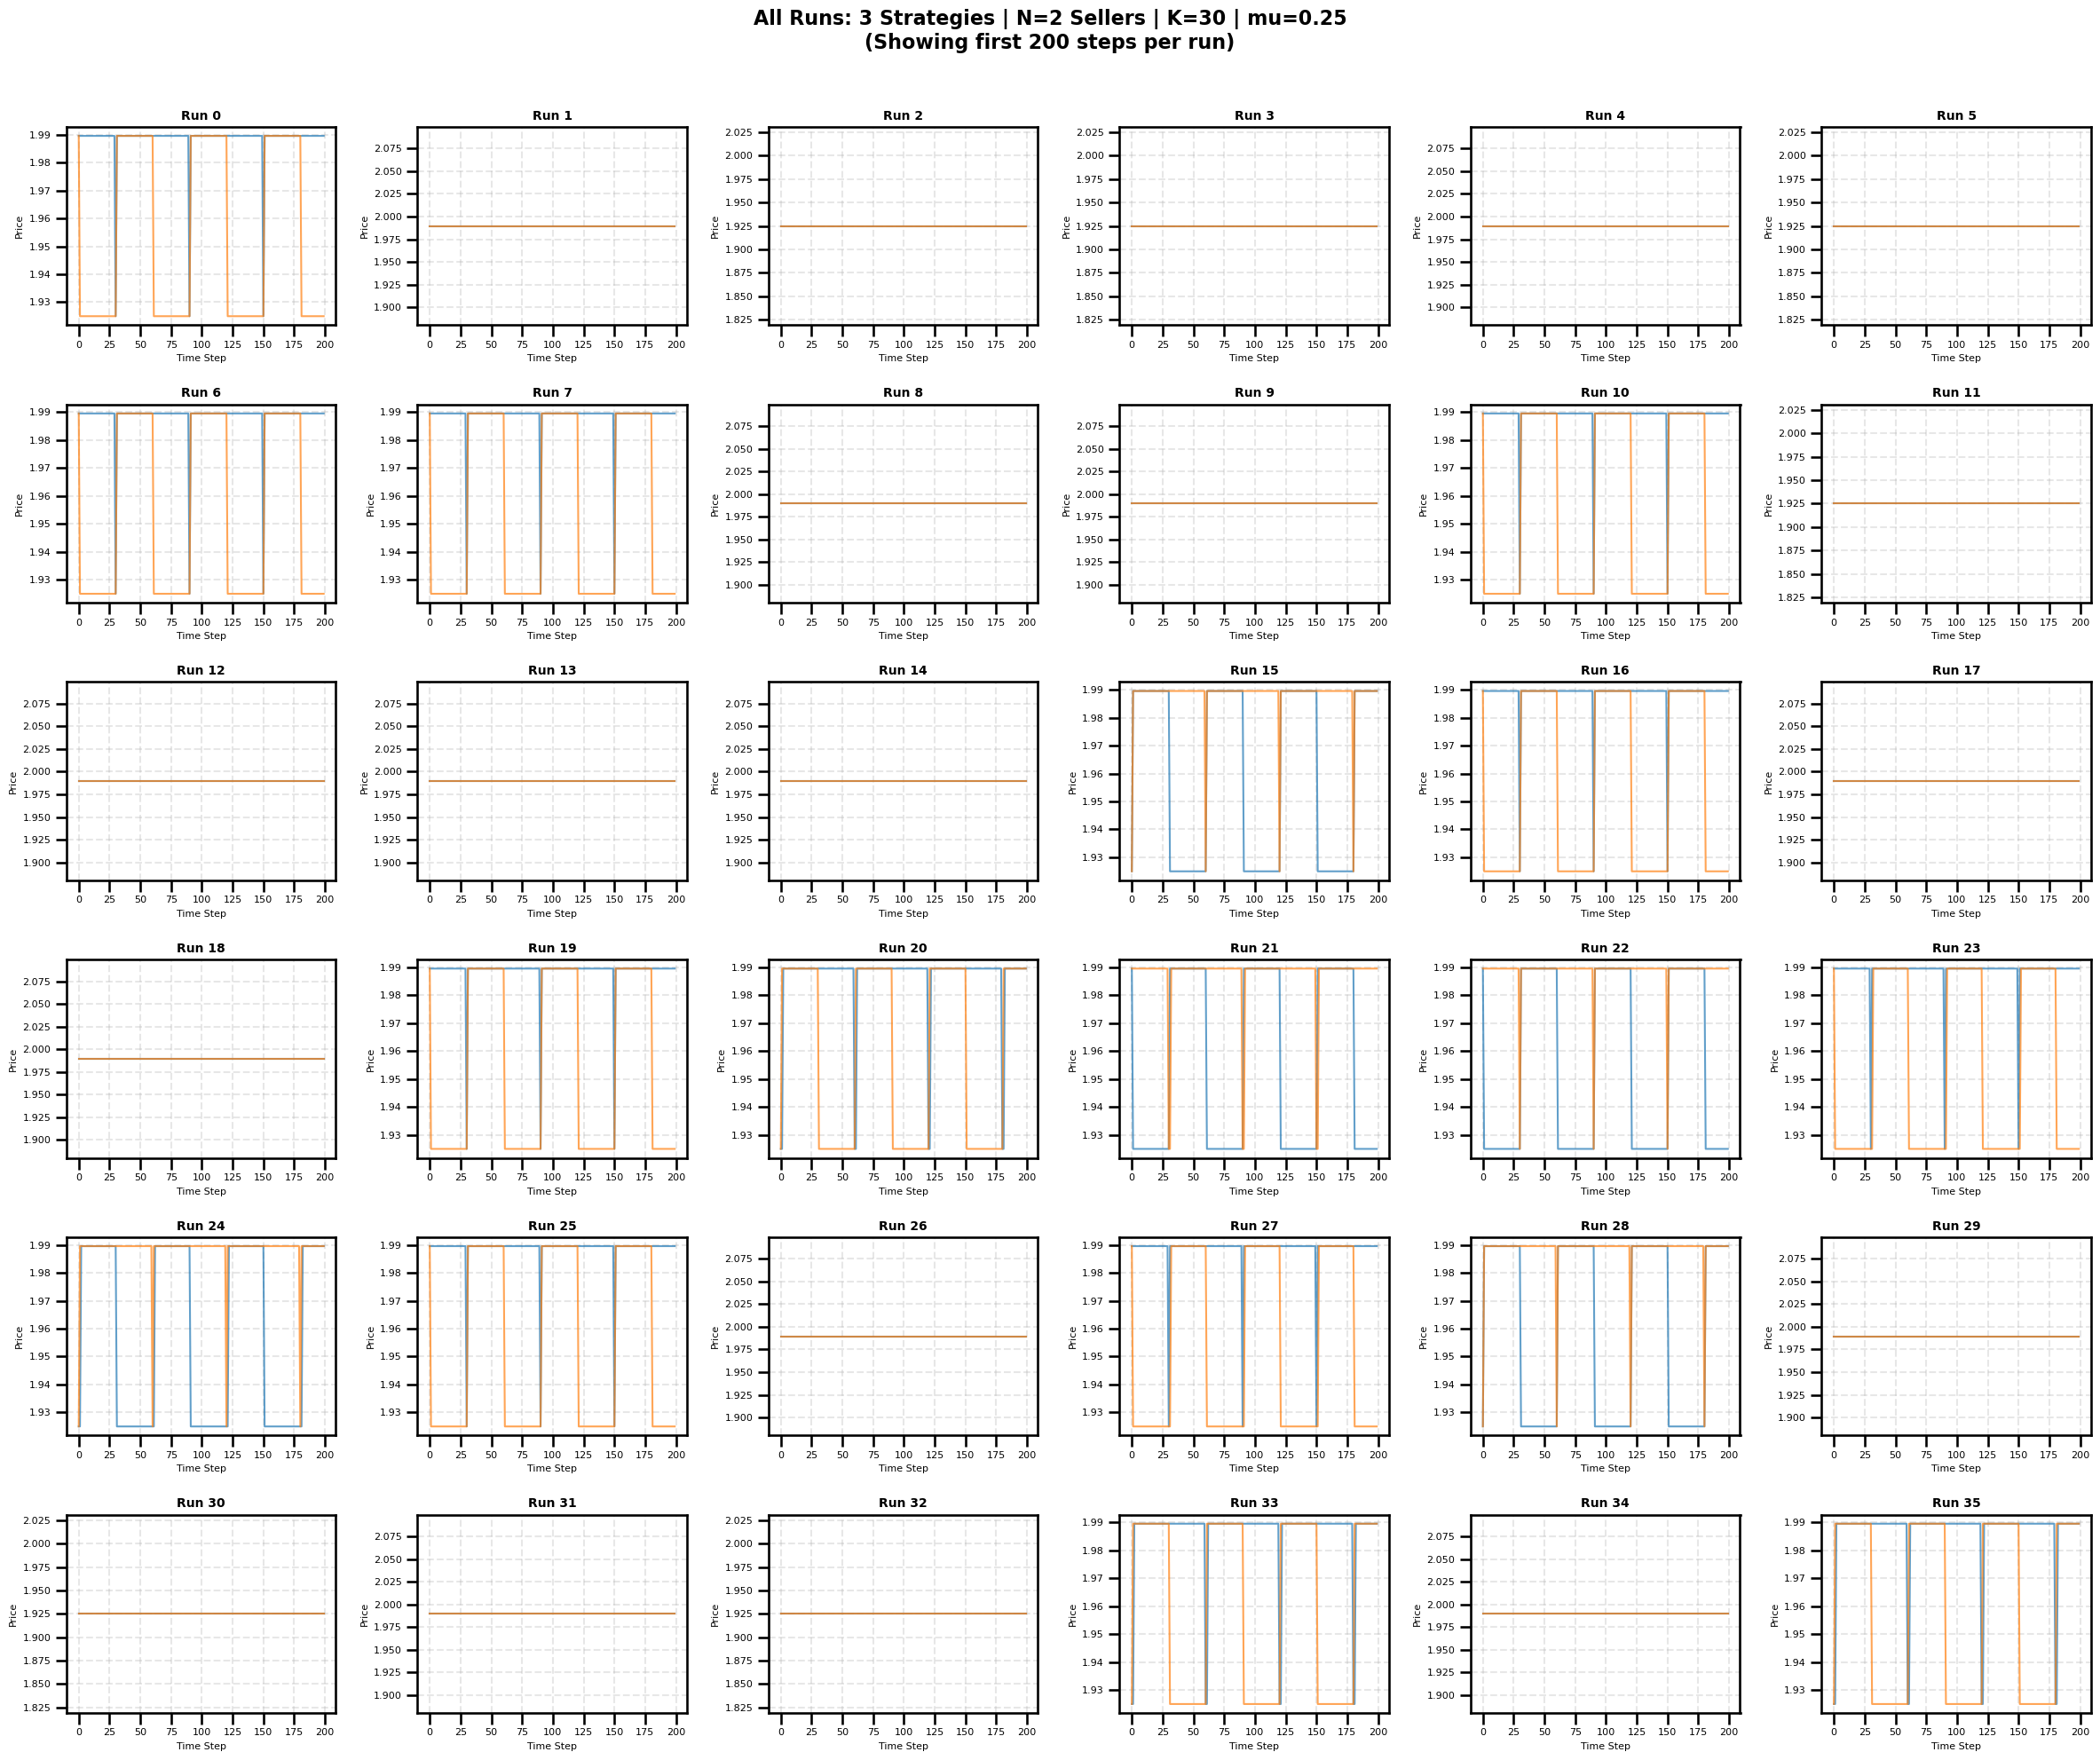

In [5]:
plot_all_runs_grid(strats=3, N=2, k=30, mu=0.25, max_steps=200)

Found 100 runs in scan_3strats_mu0.16_k40/N_10


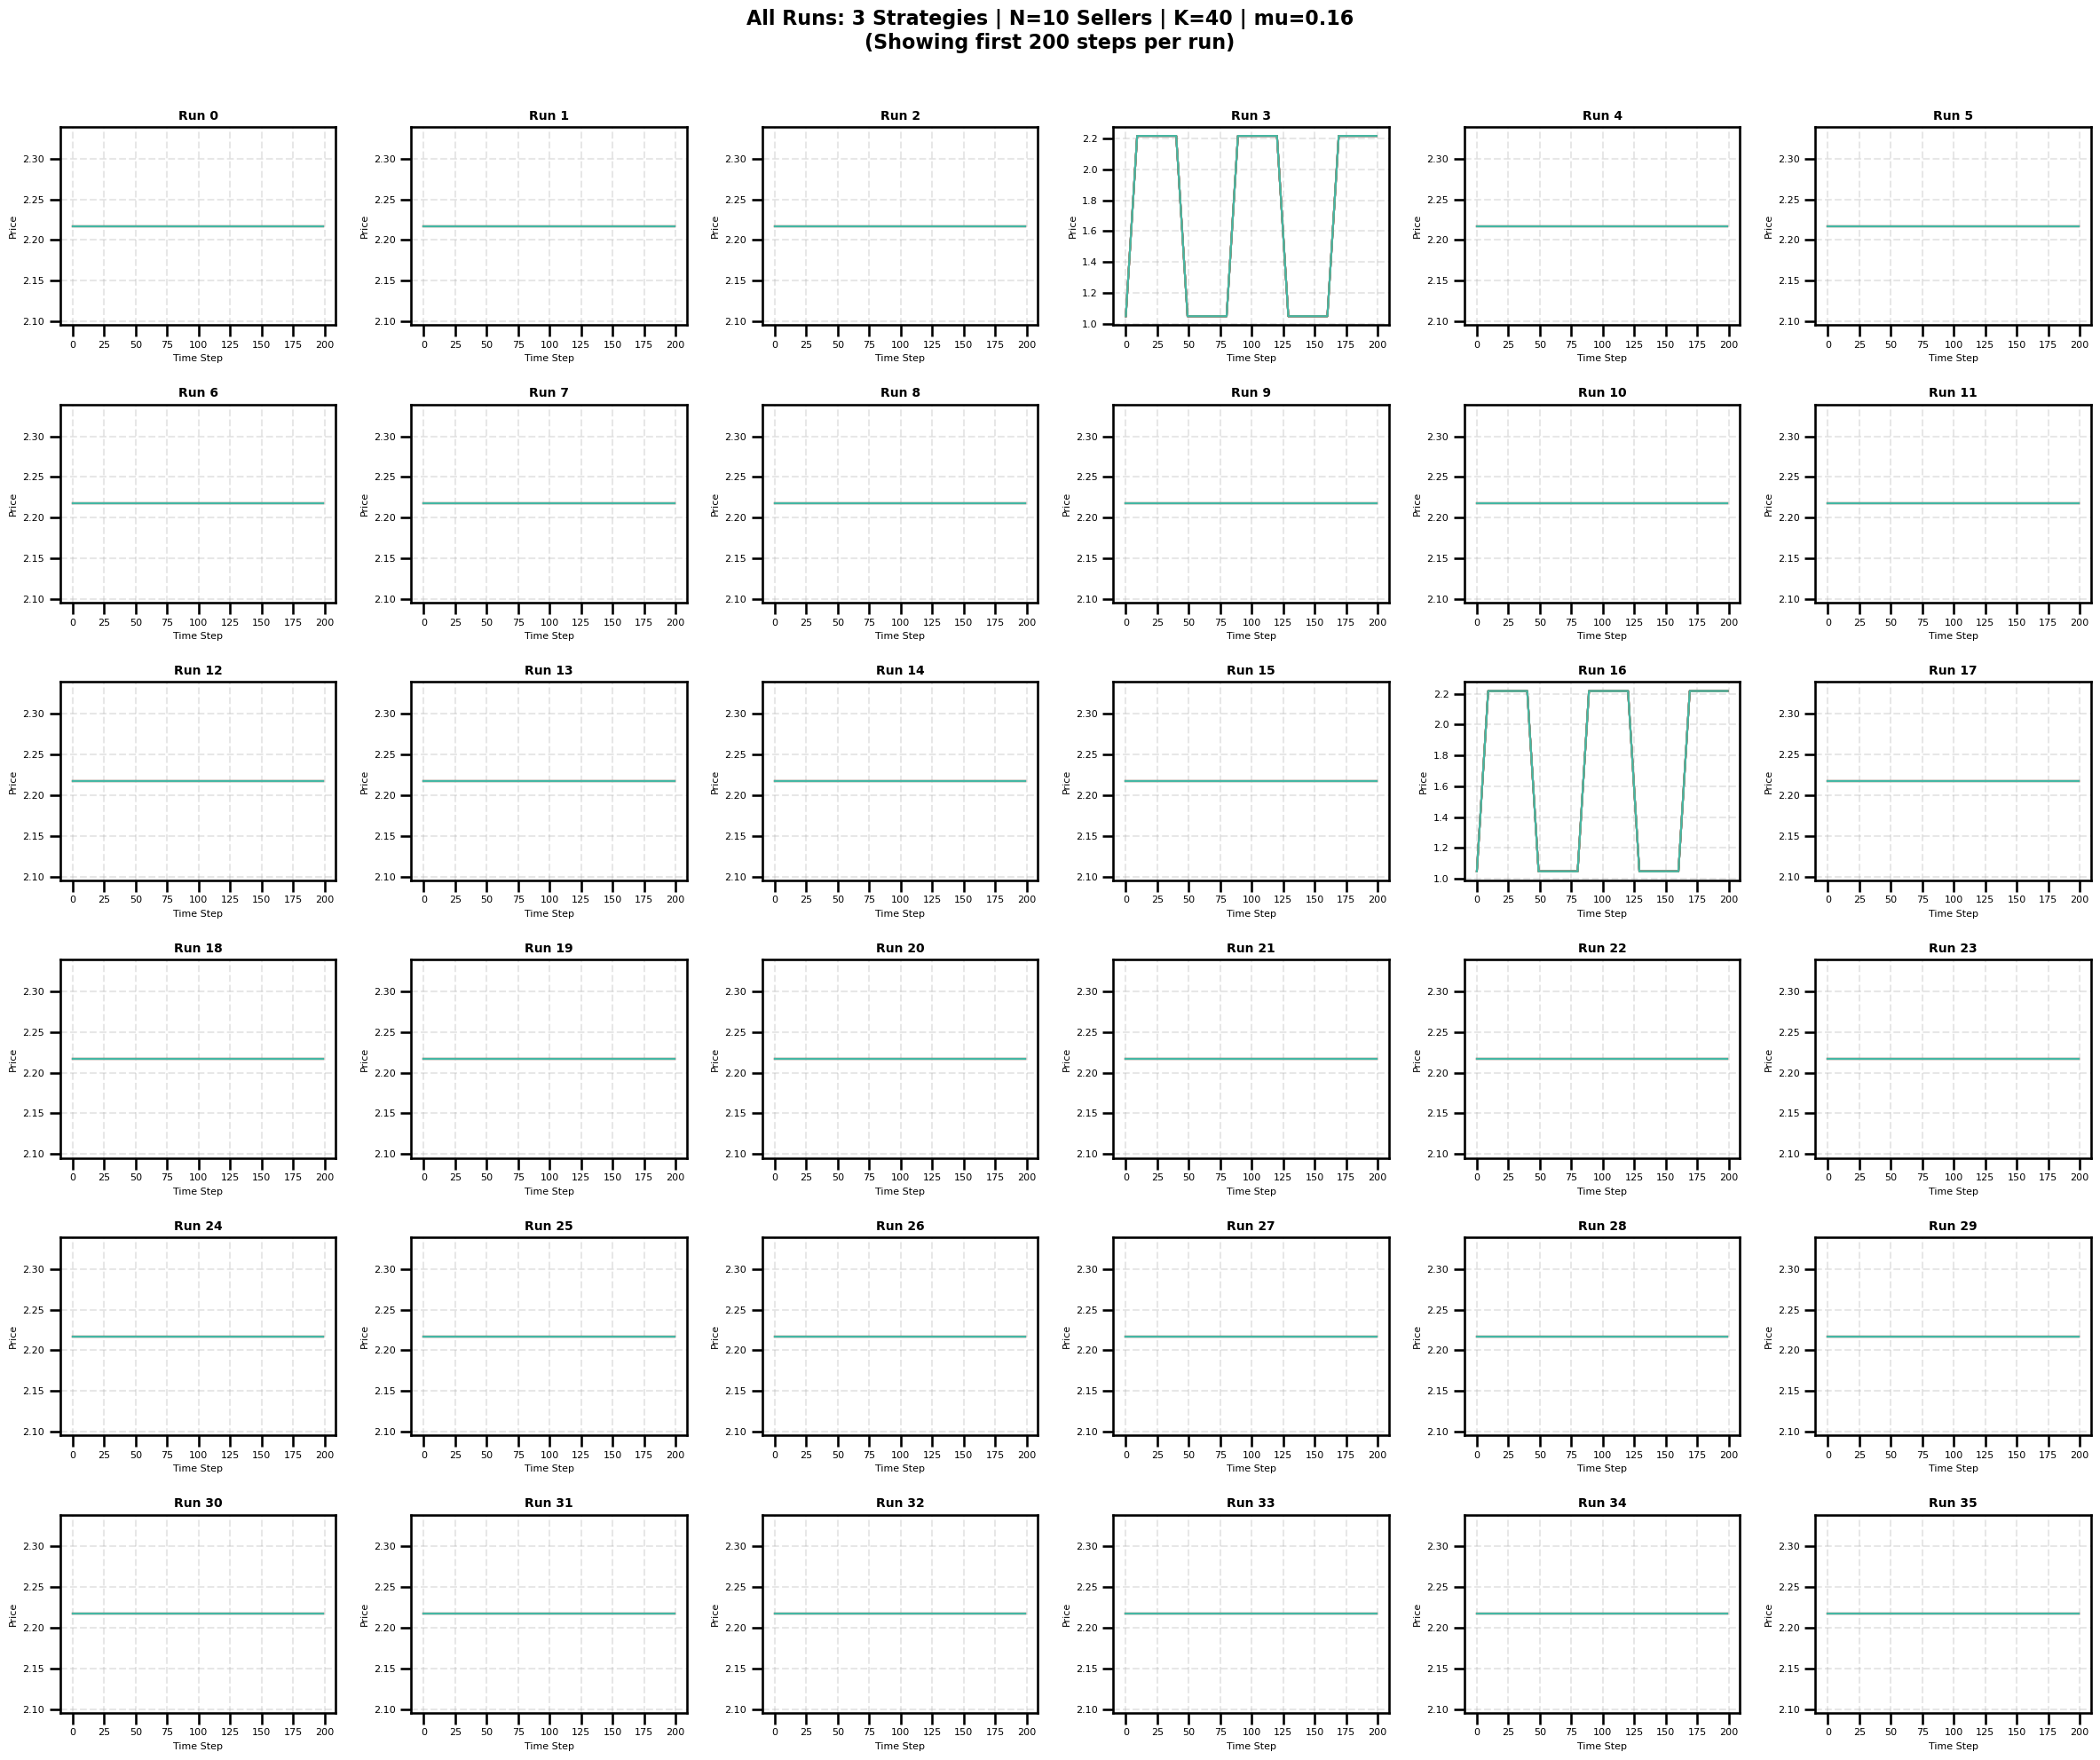

In [44]:
plot_all_runs_grid(strats=3, N=10, k=40, mu=0.16, max_steps=200)

Found 100 runs in scan_4strats_mu0.16_k40/N_10


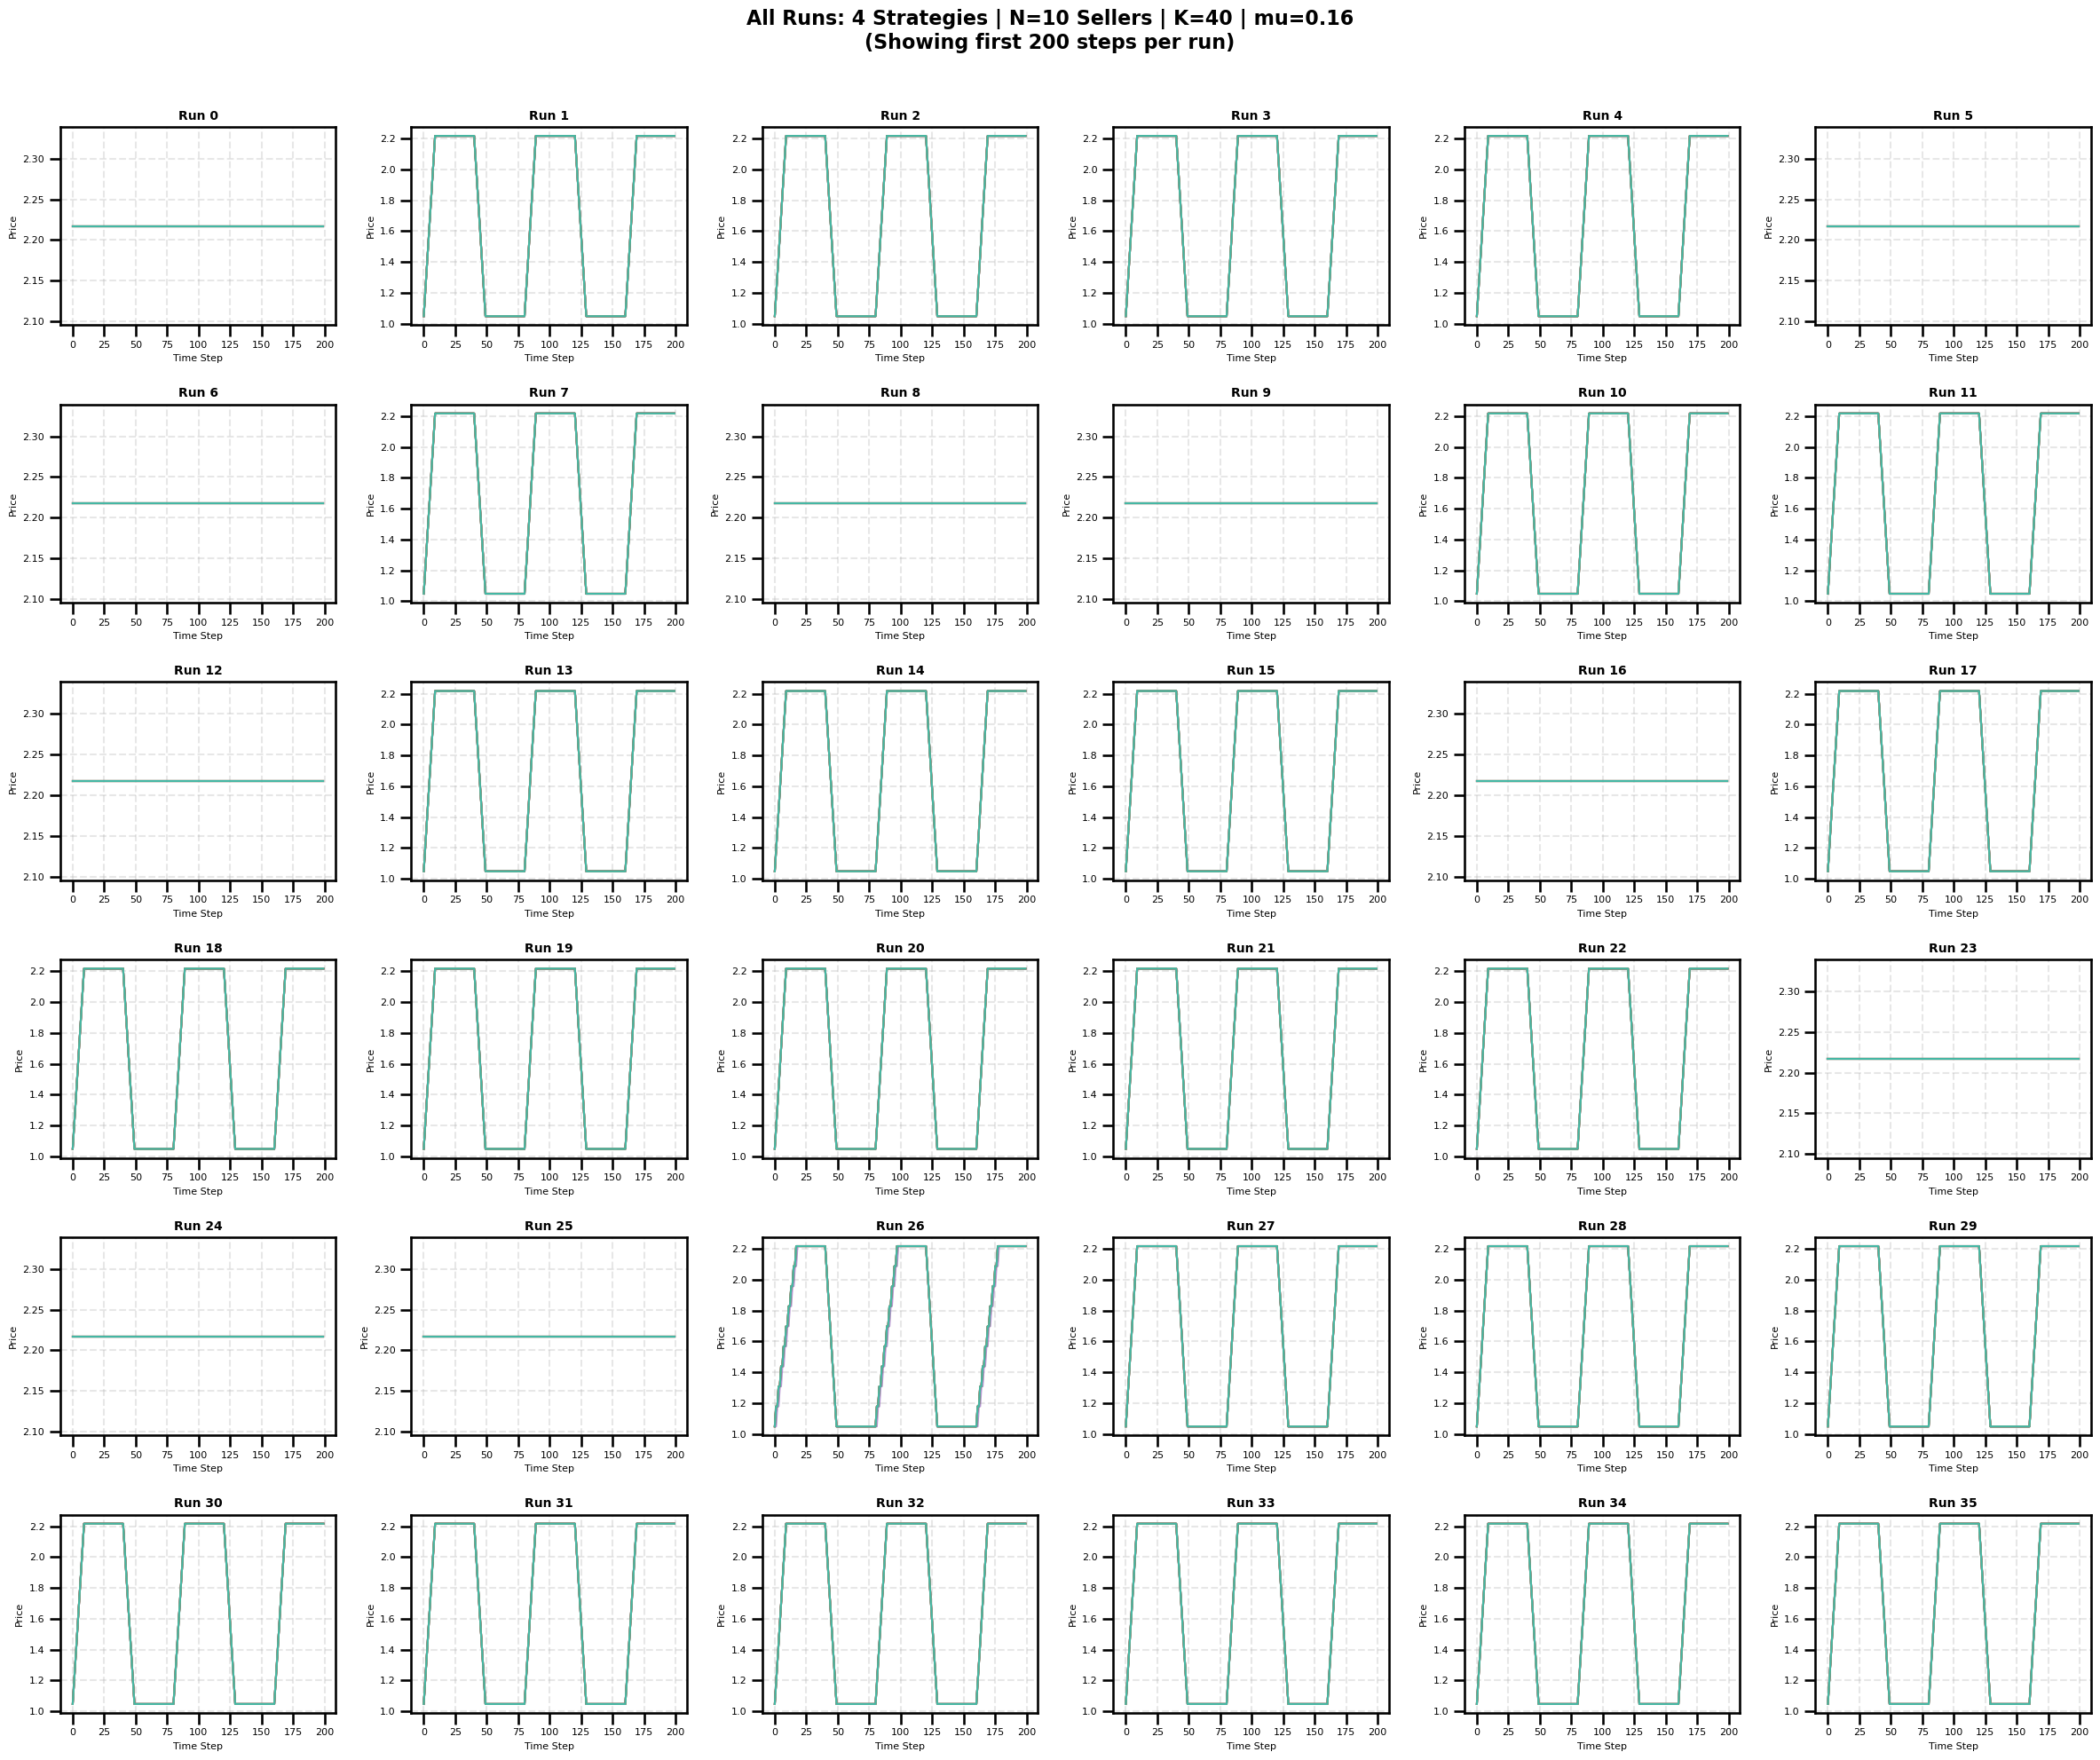

In [45]:
plot_all_runs_grid(strats=4, N=10, k=40, mu=0.16, max_steps=200)

Found 100 runs in scan_3strats_mu0.19_k40/N_10


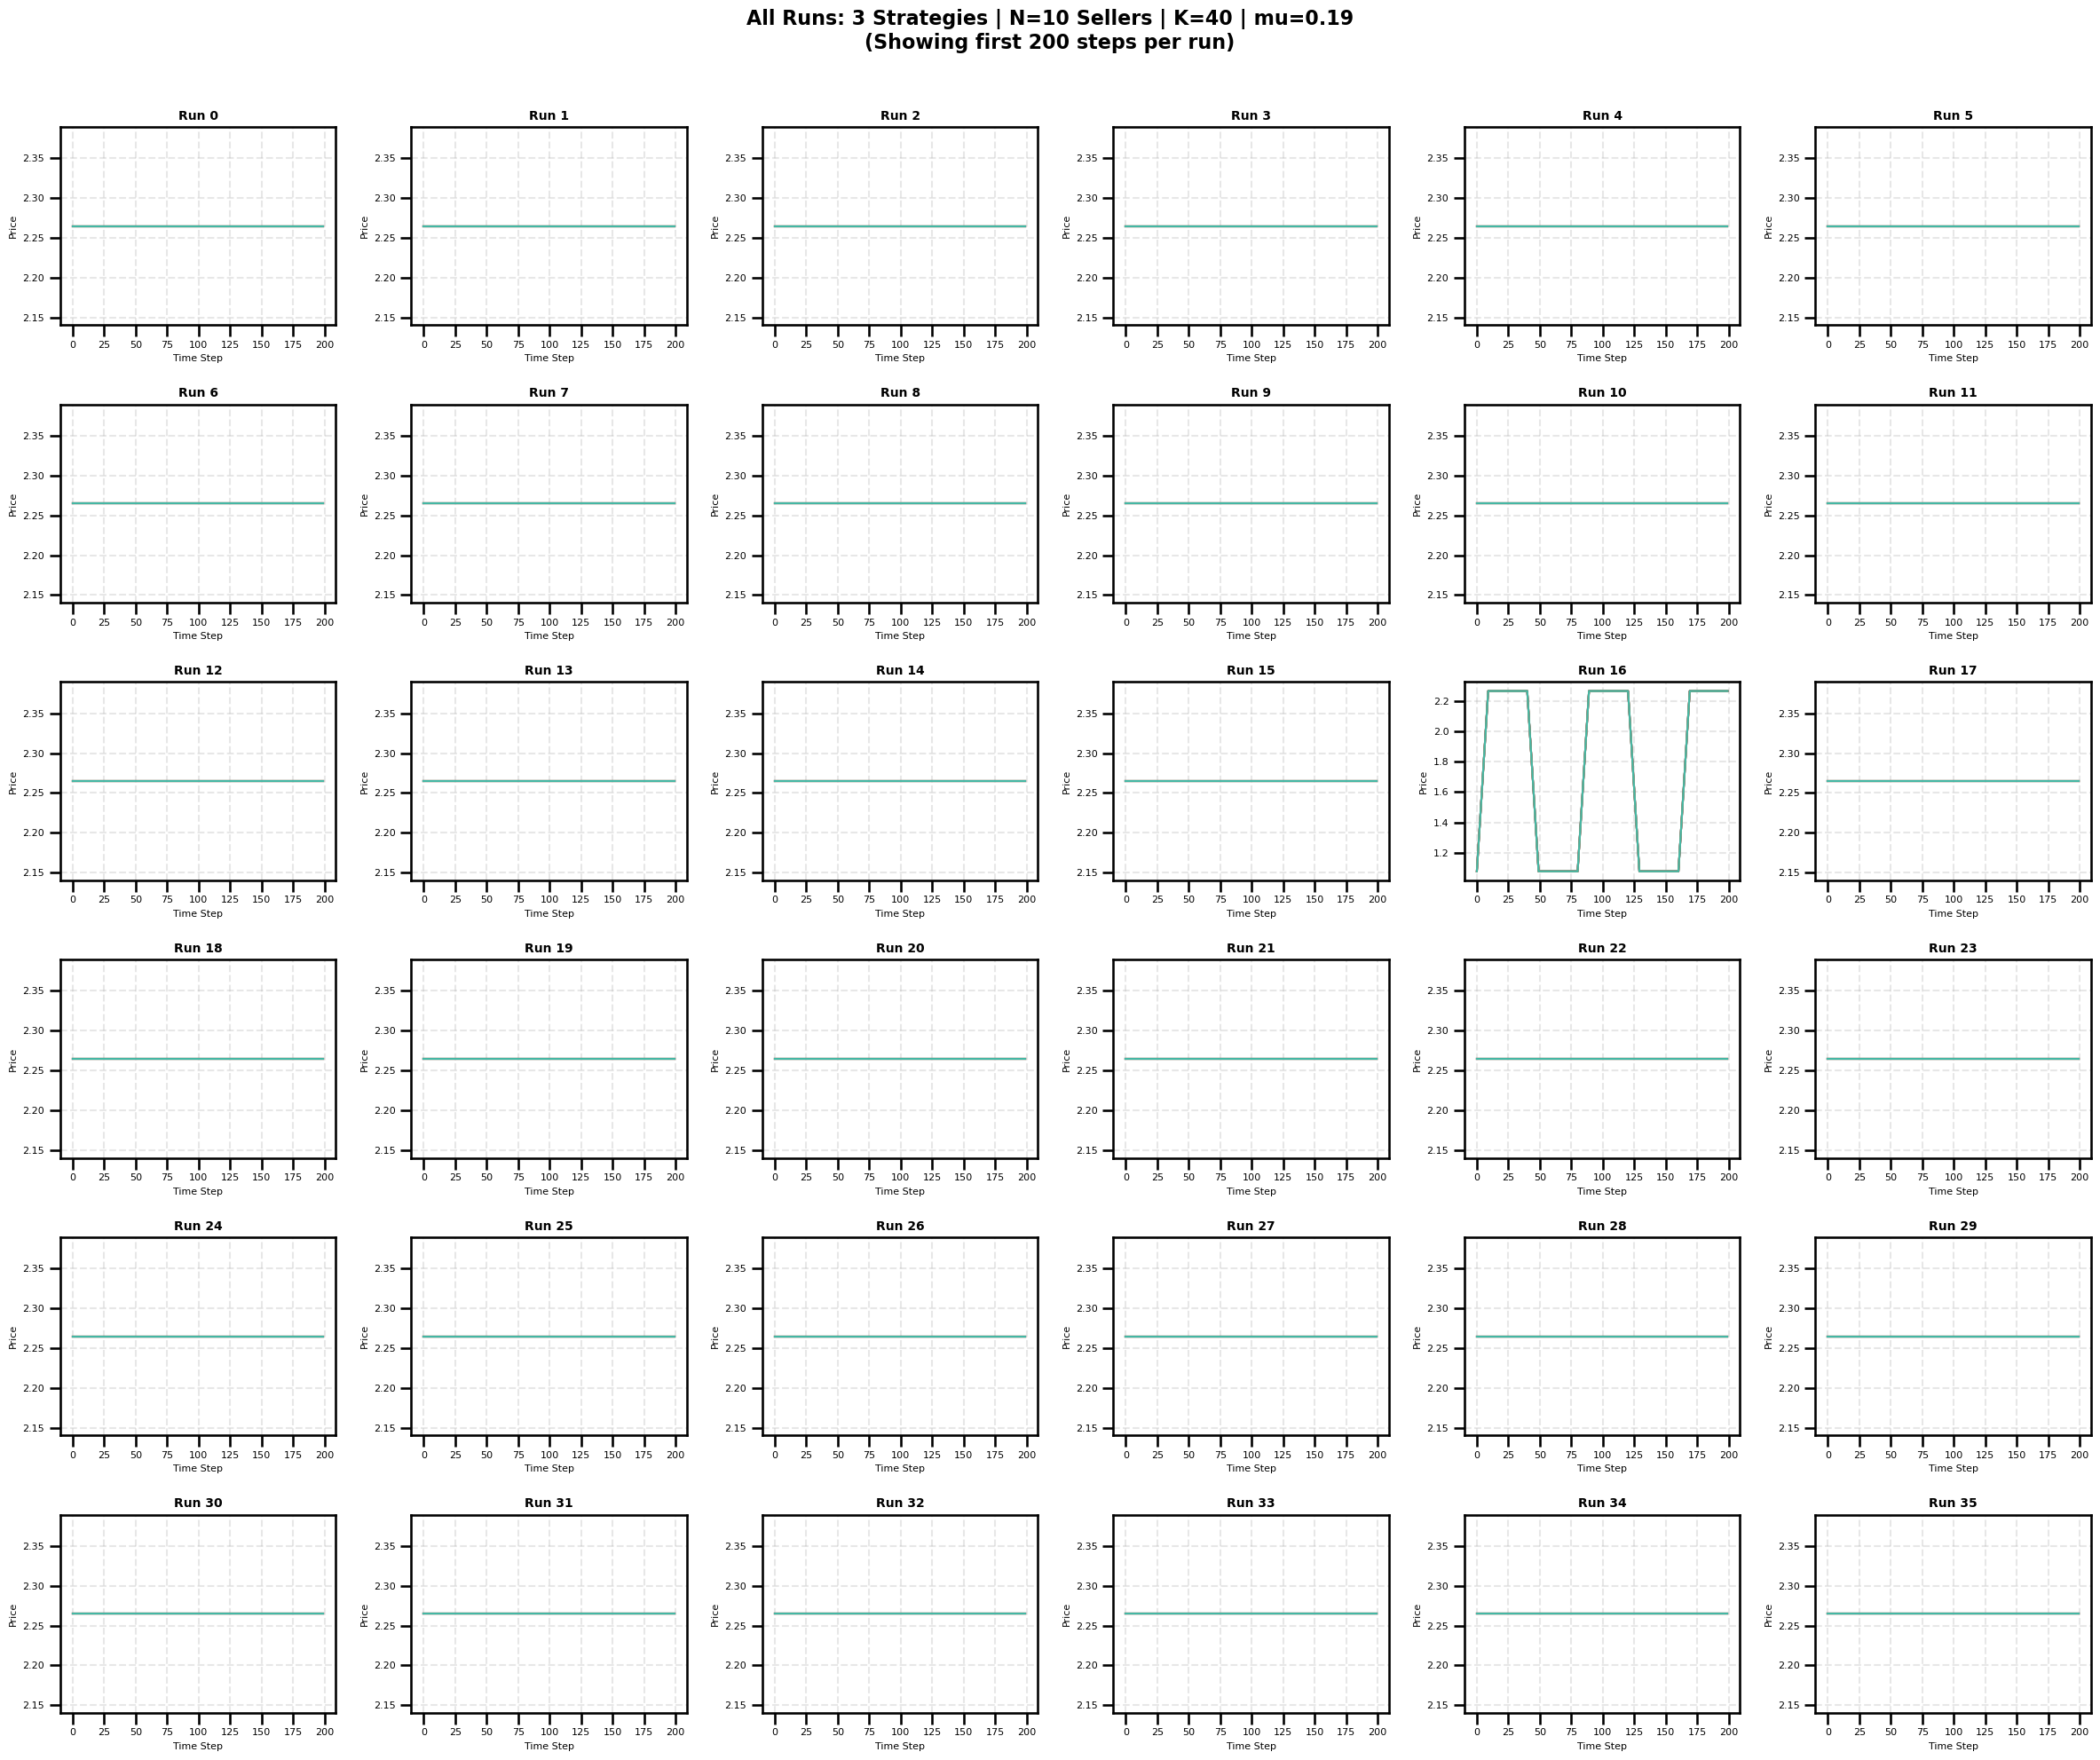

In [46]:
plot_all_runs_grid(strats=3, N=10, k=40, mu=0.19, max_steps=200)

Found 100 runs in scan_4strats_mu0.19_k40/N_10


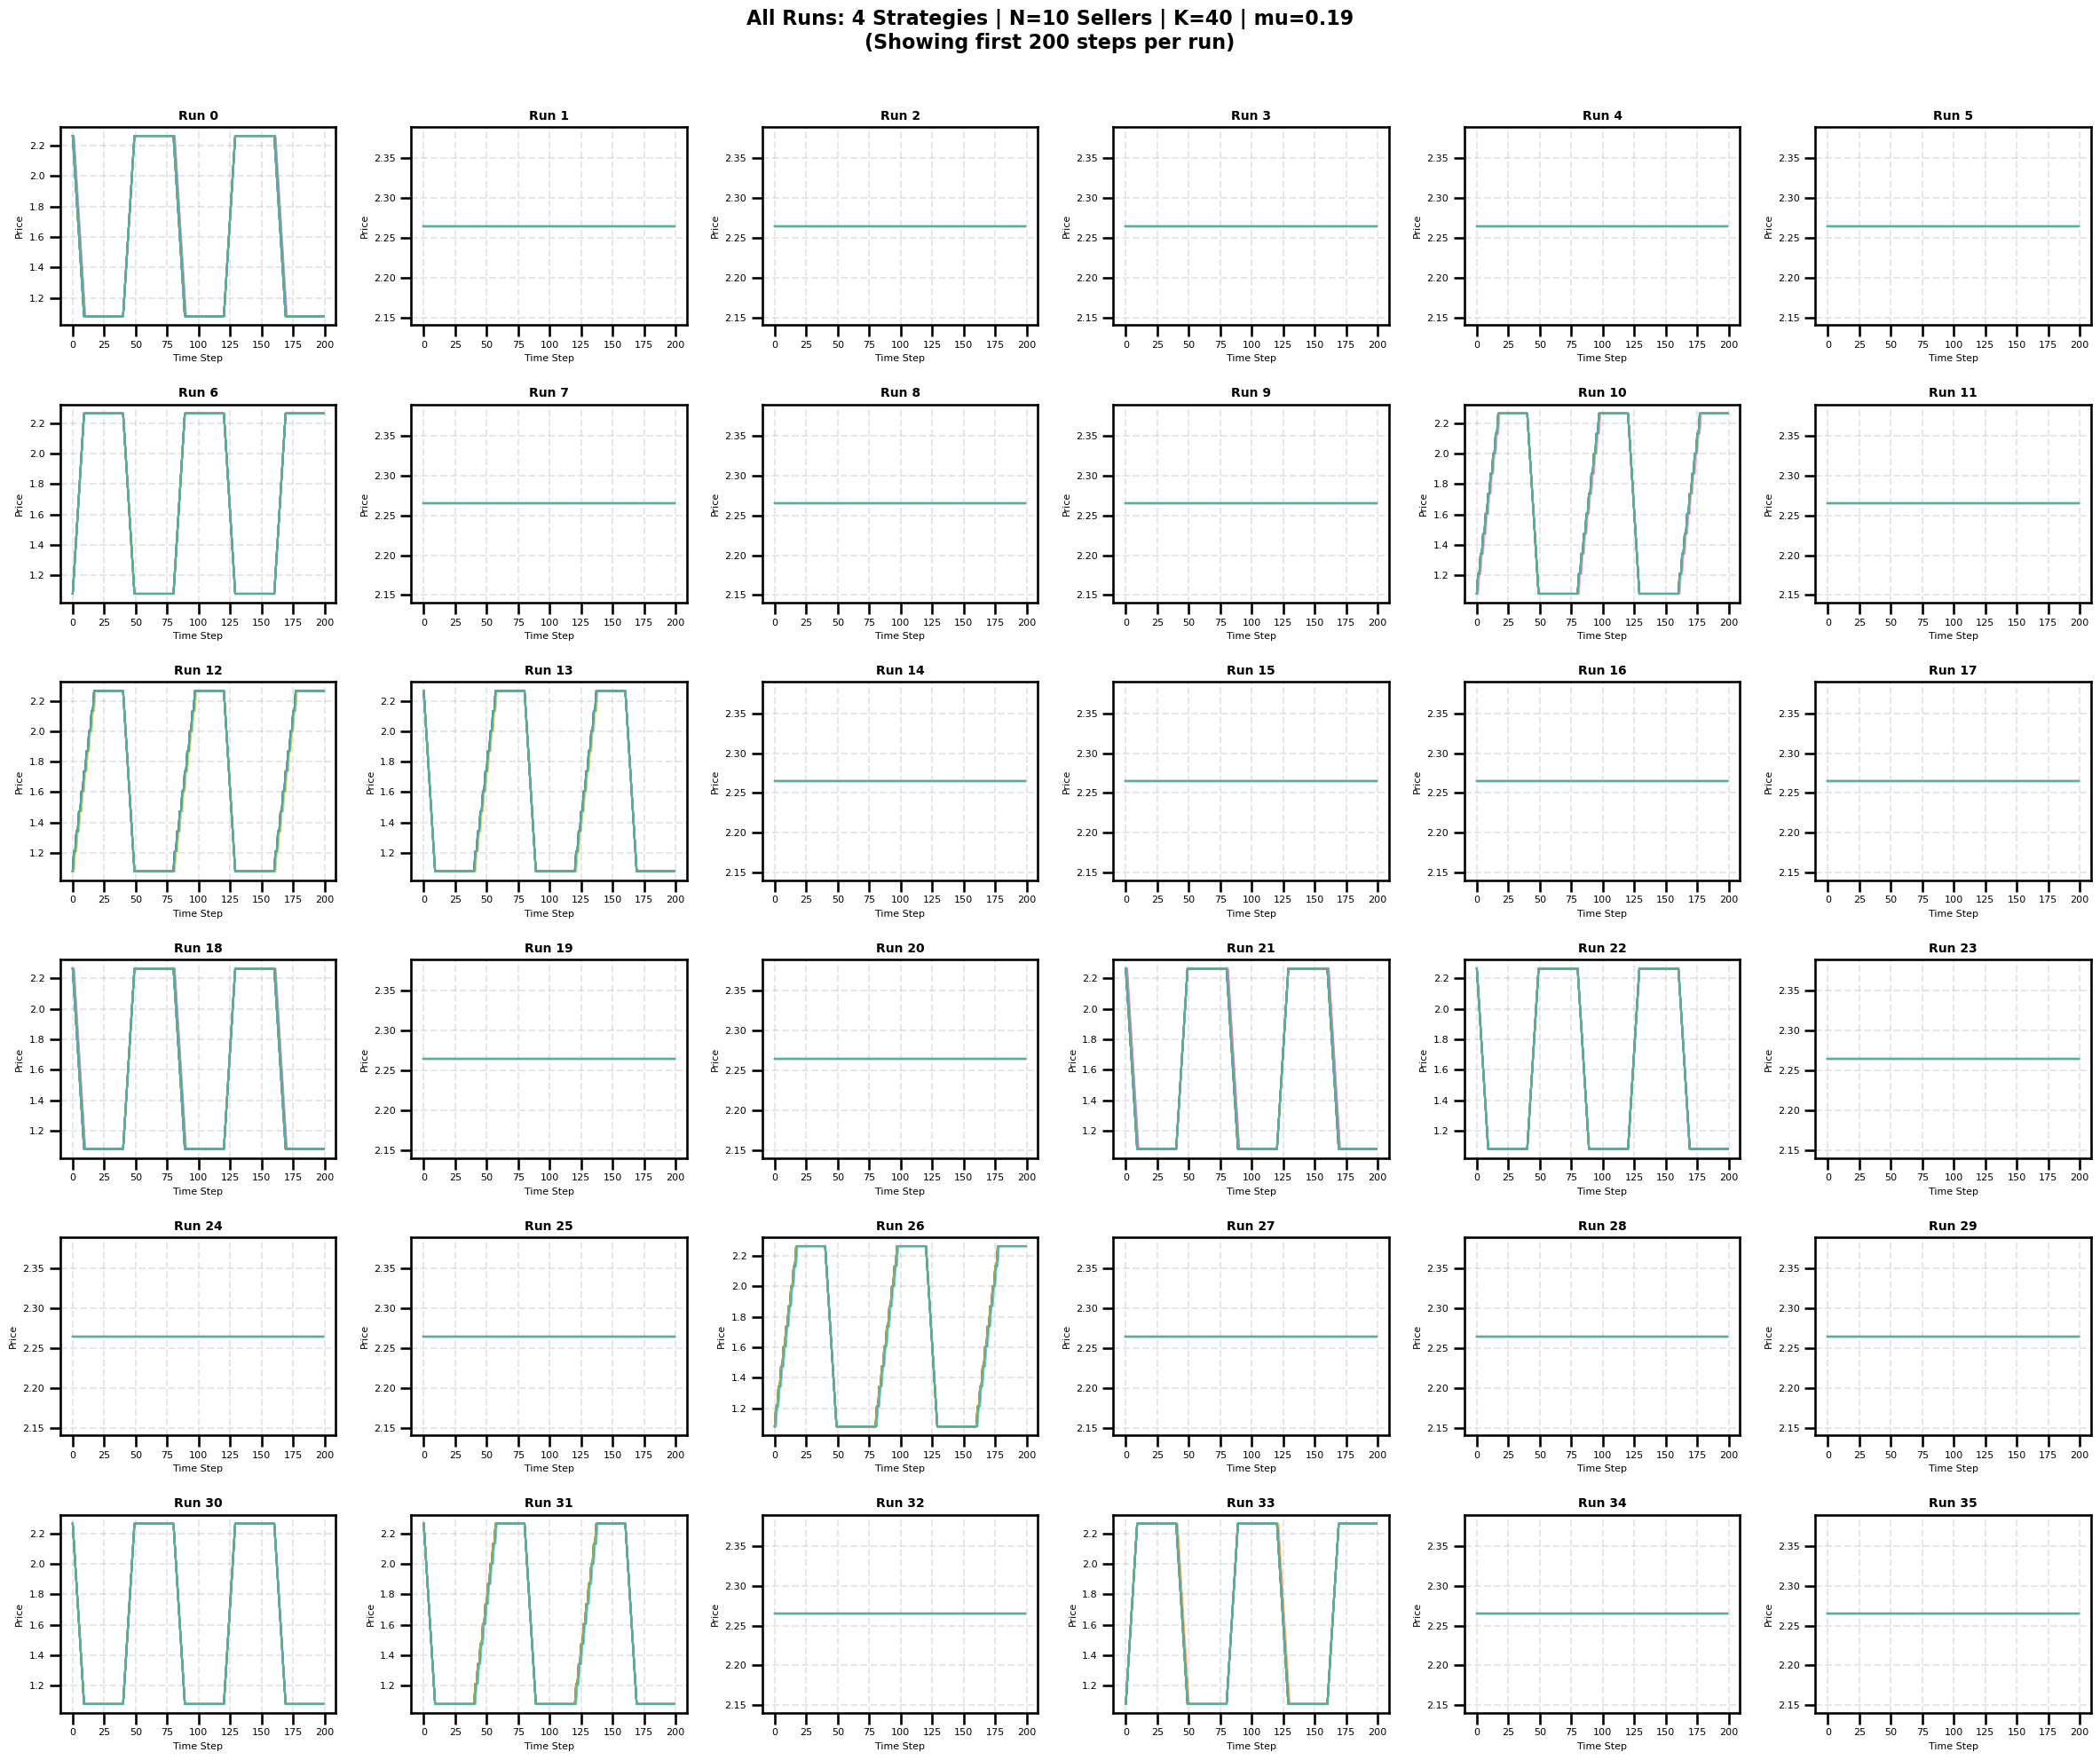

In [47]:
plot_all_runs_grid(strats=4, N=10, k=40, mu=0.19, max_steps=200)

Found 100 runs in scan_3strats_mu0.04_k30/N_10


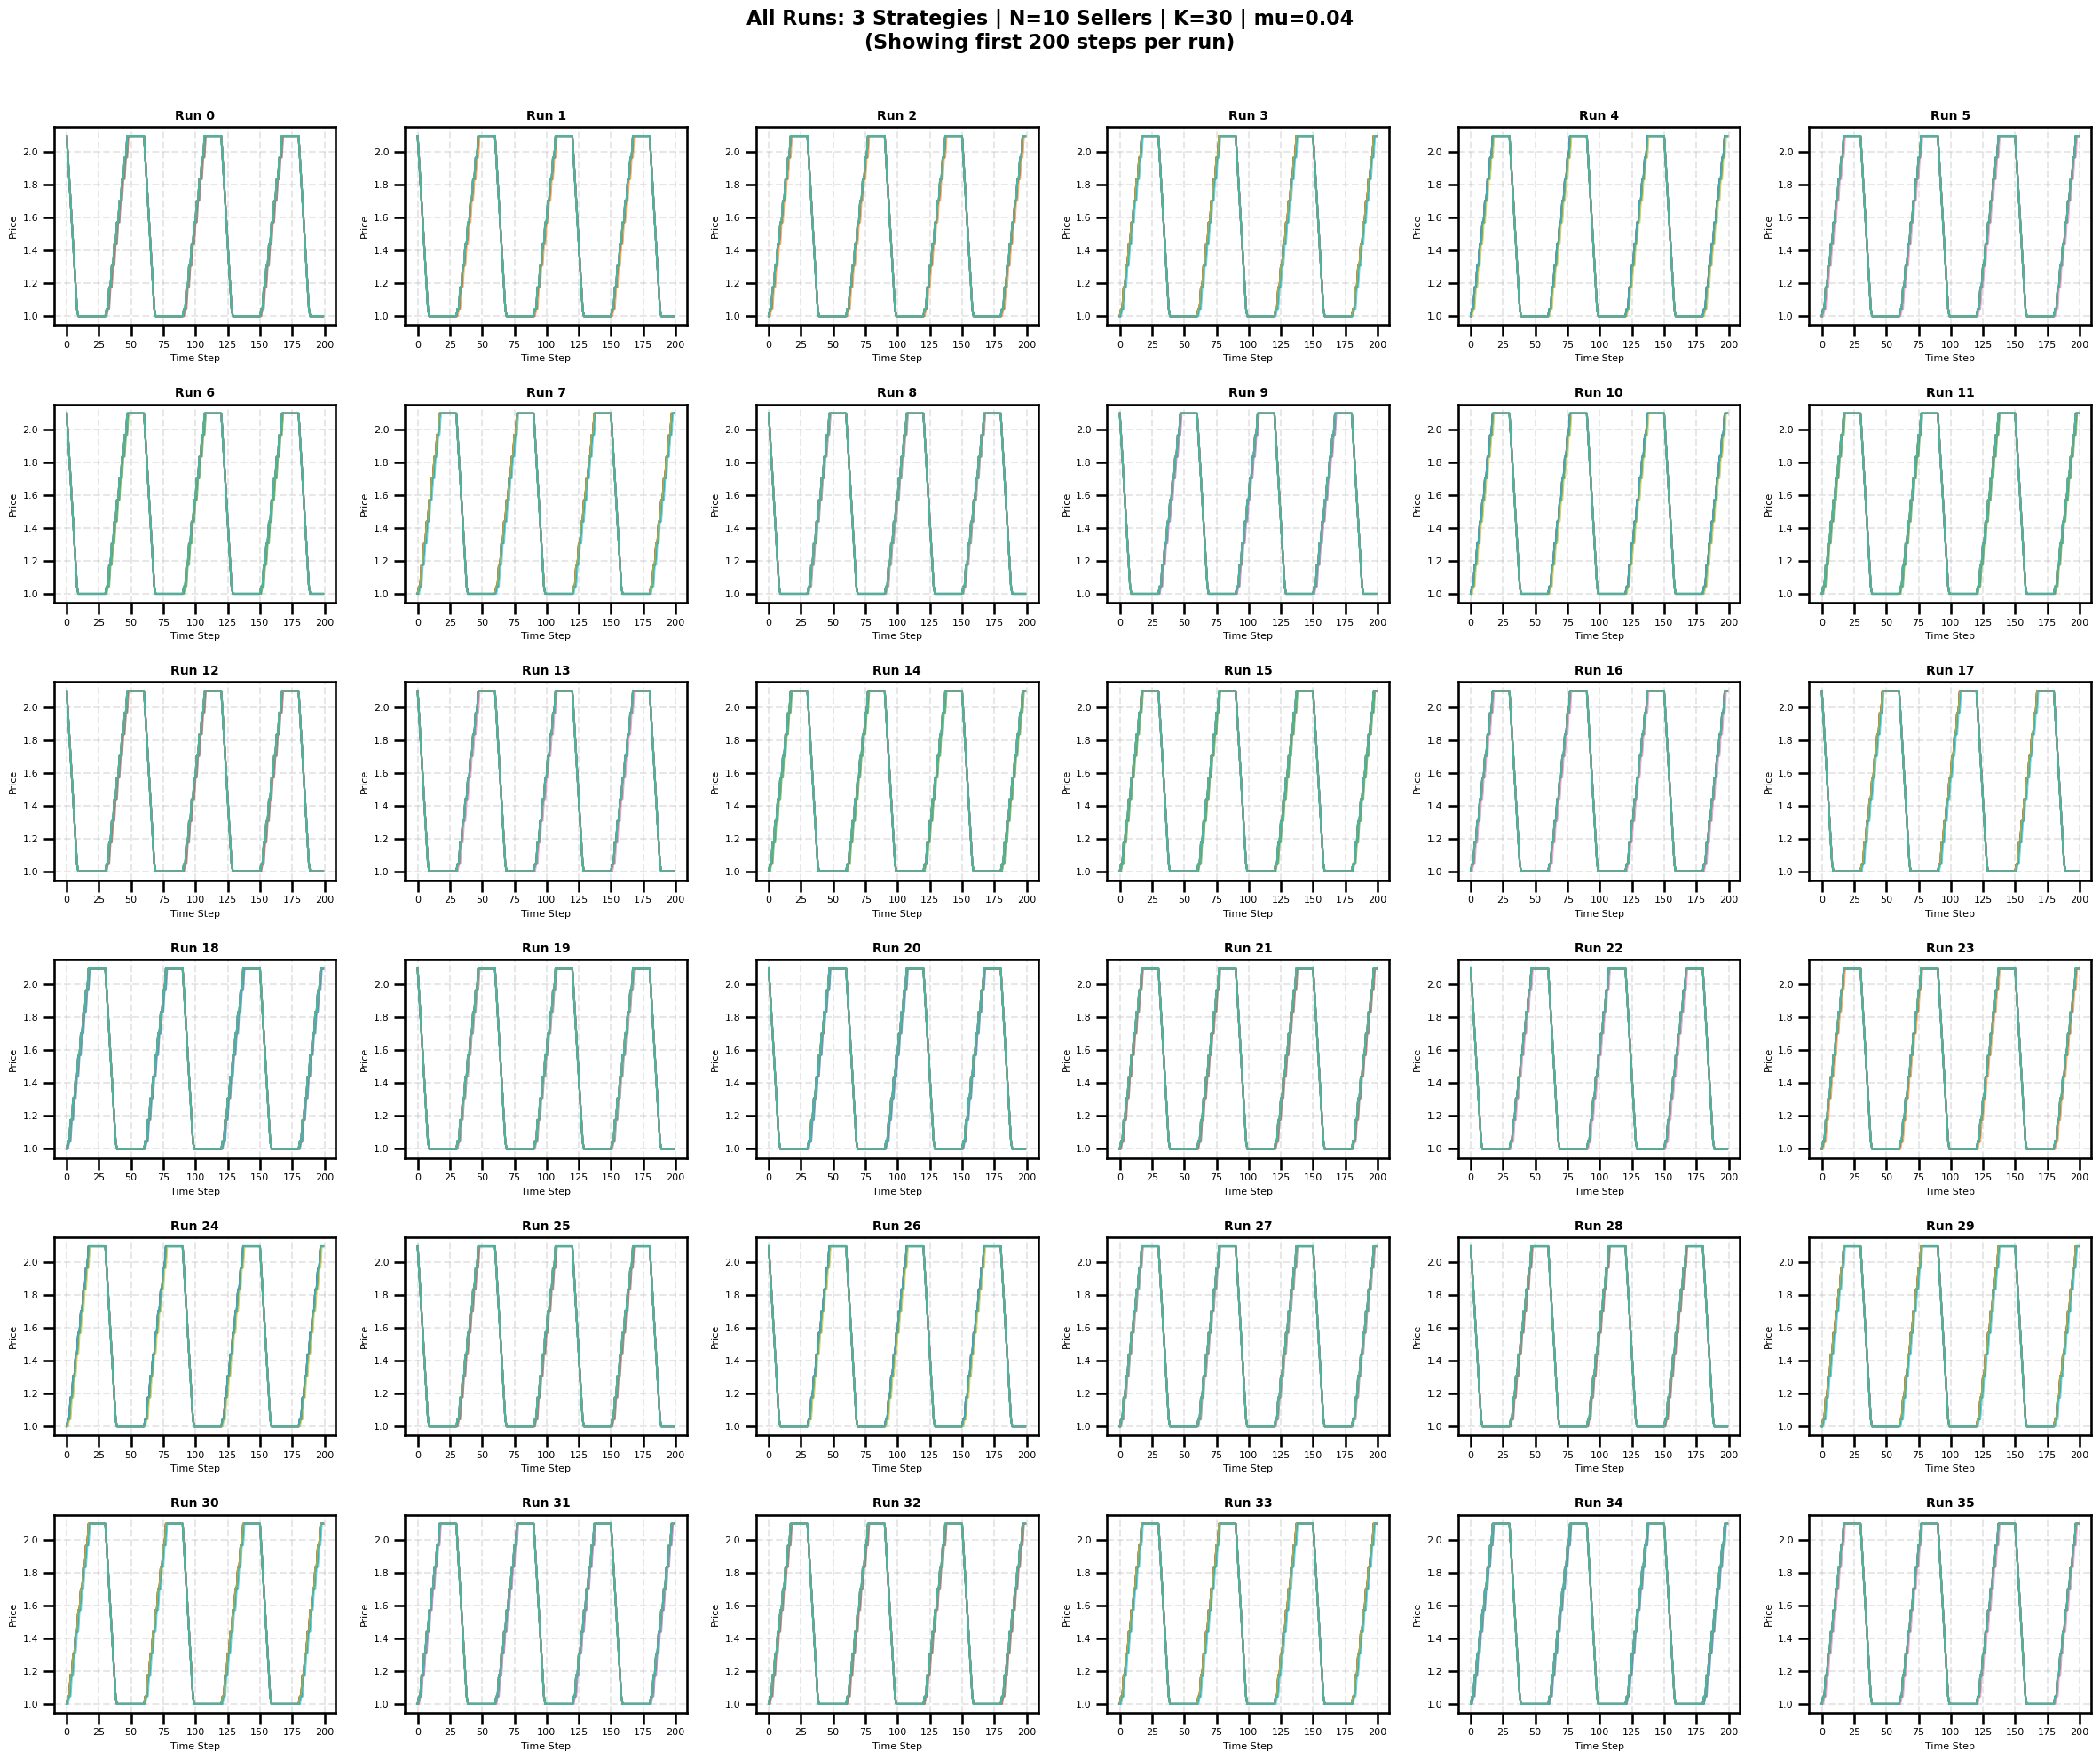

In [48]:
plot_all_runs_grid(strats=3, N=10, k=30, mu=0.04, max_steps=200)

Found 100 runs in scan_3strats_mu0.1_k30/N_10


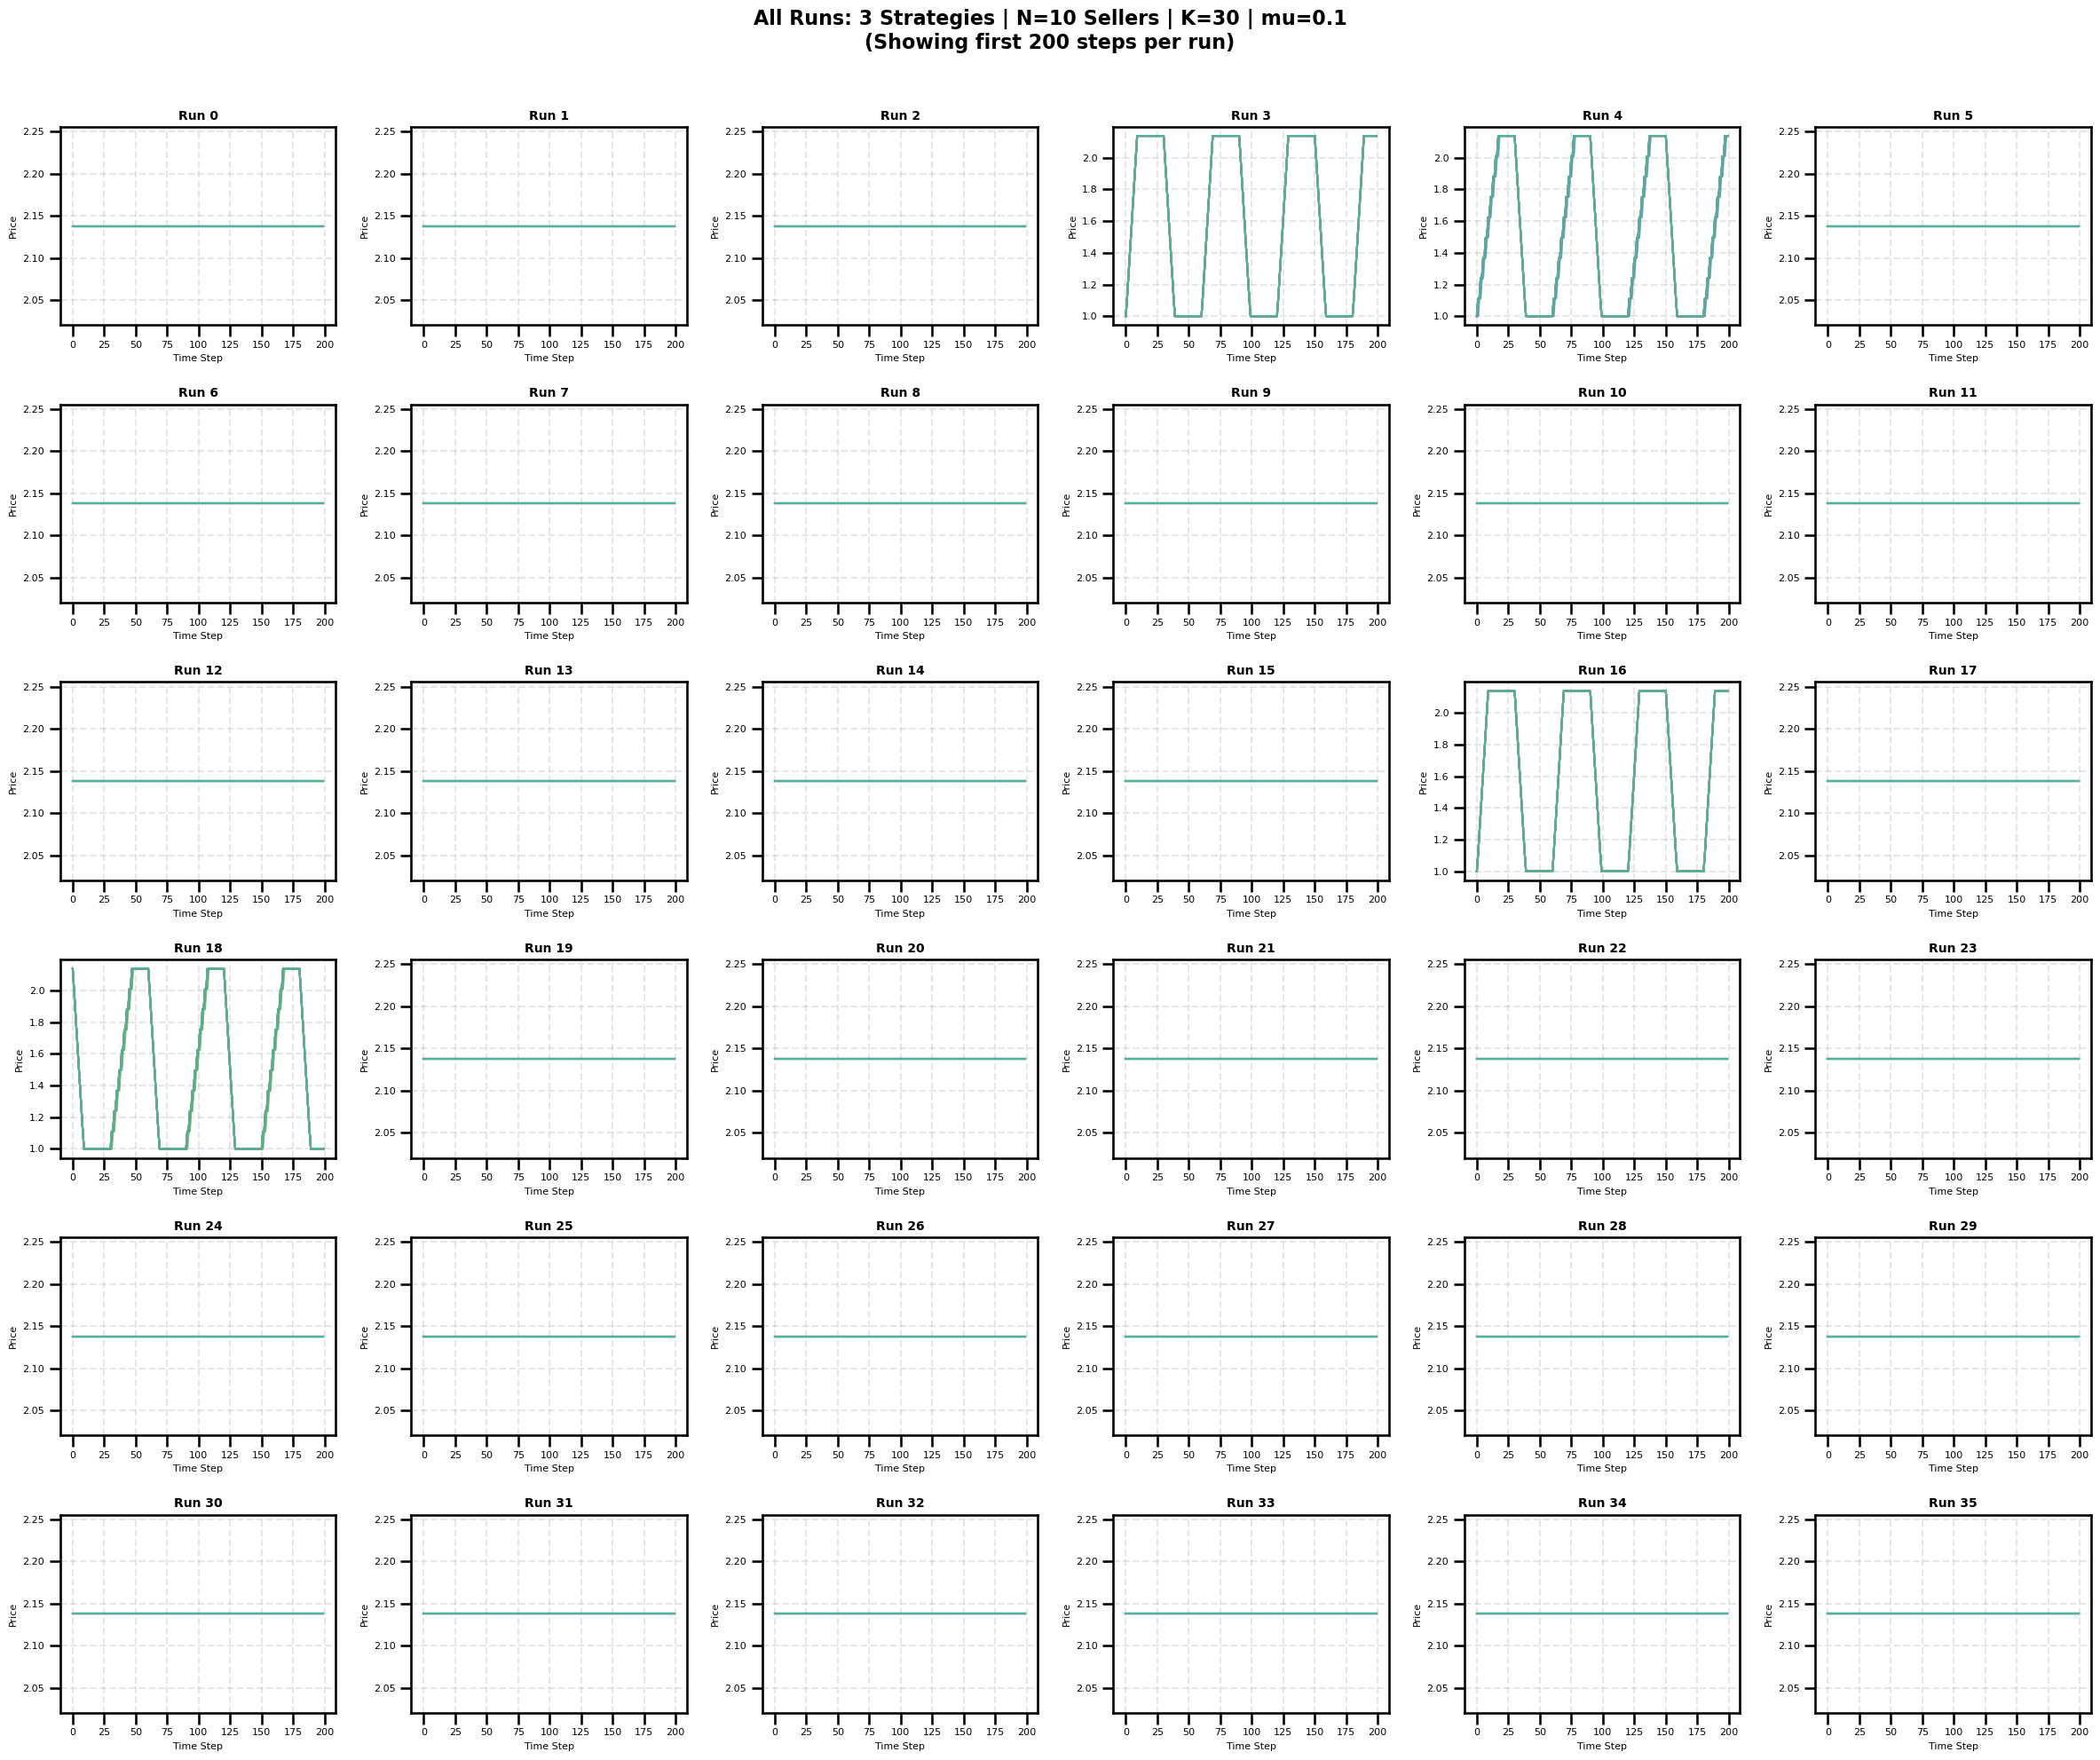

In [49]:
plot_all_runs_grid(strats=3, N=10, k=30, mu=0.1, max_steps=200)

Found 100 runs in scan_3strats_mu0.25_k30/N_10


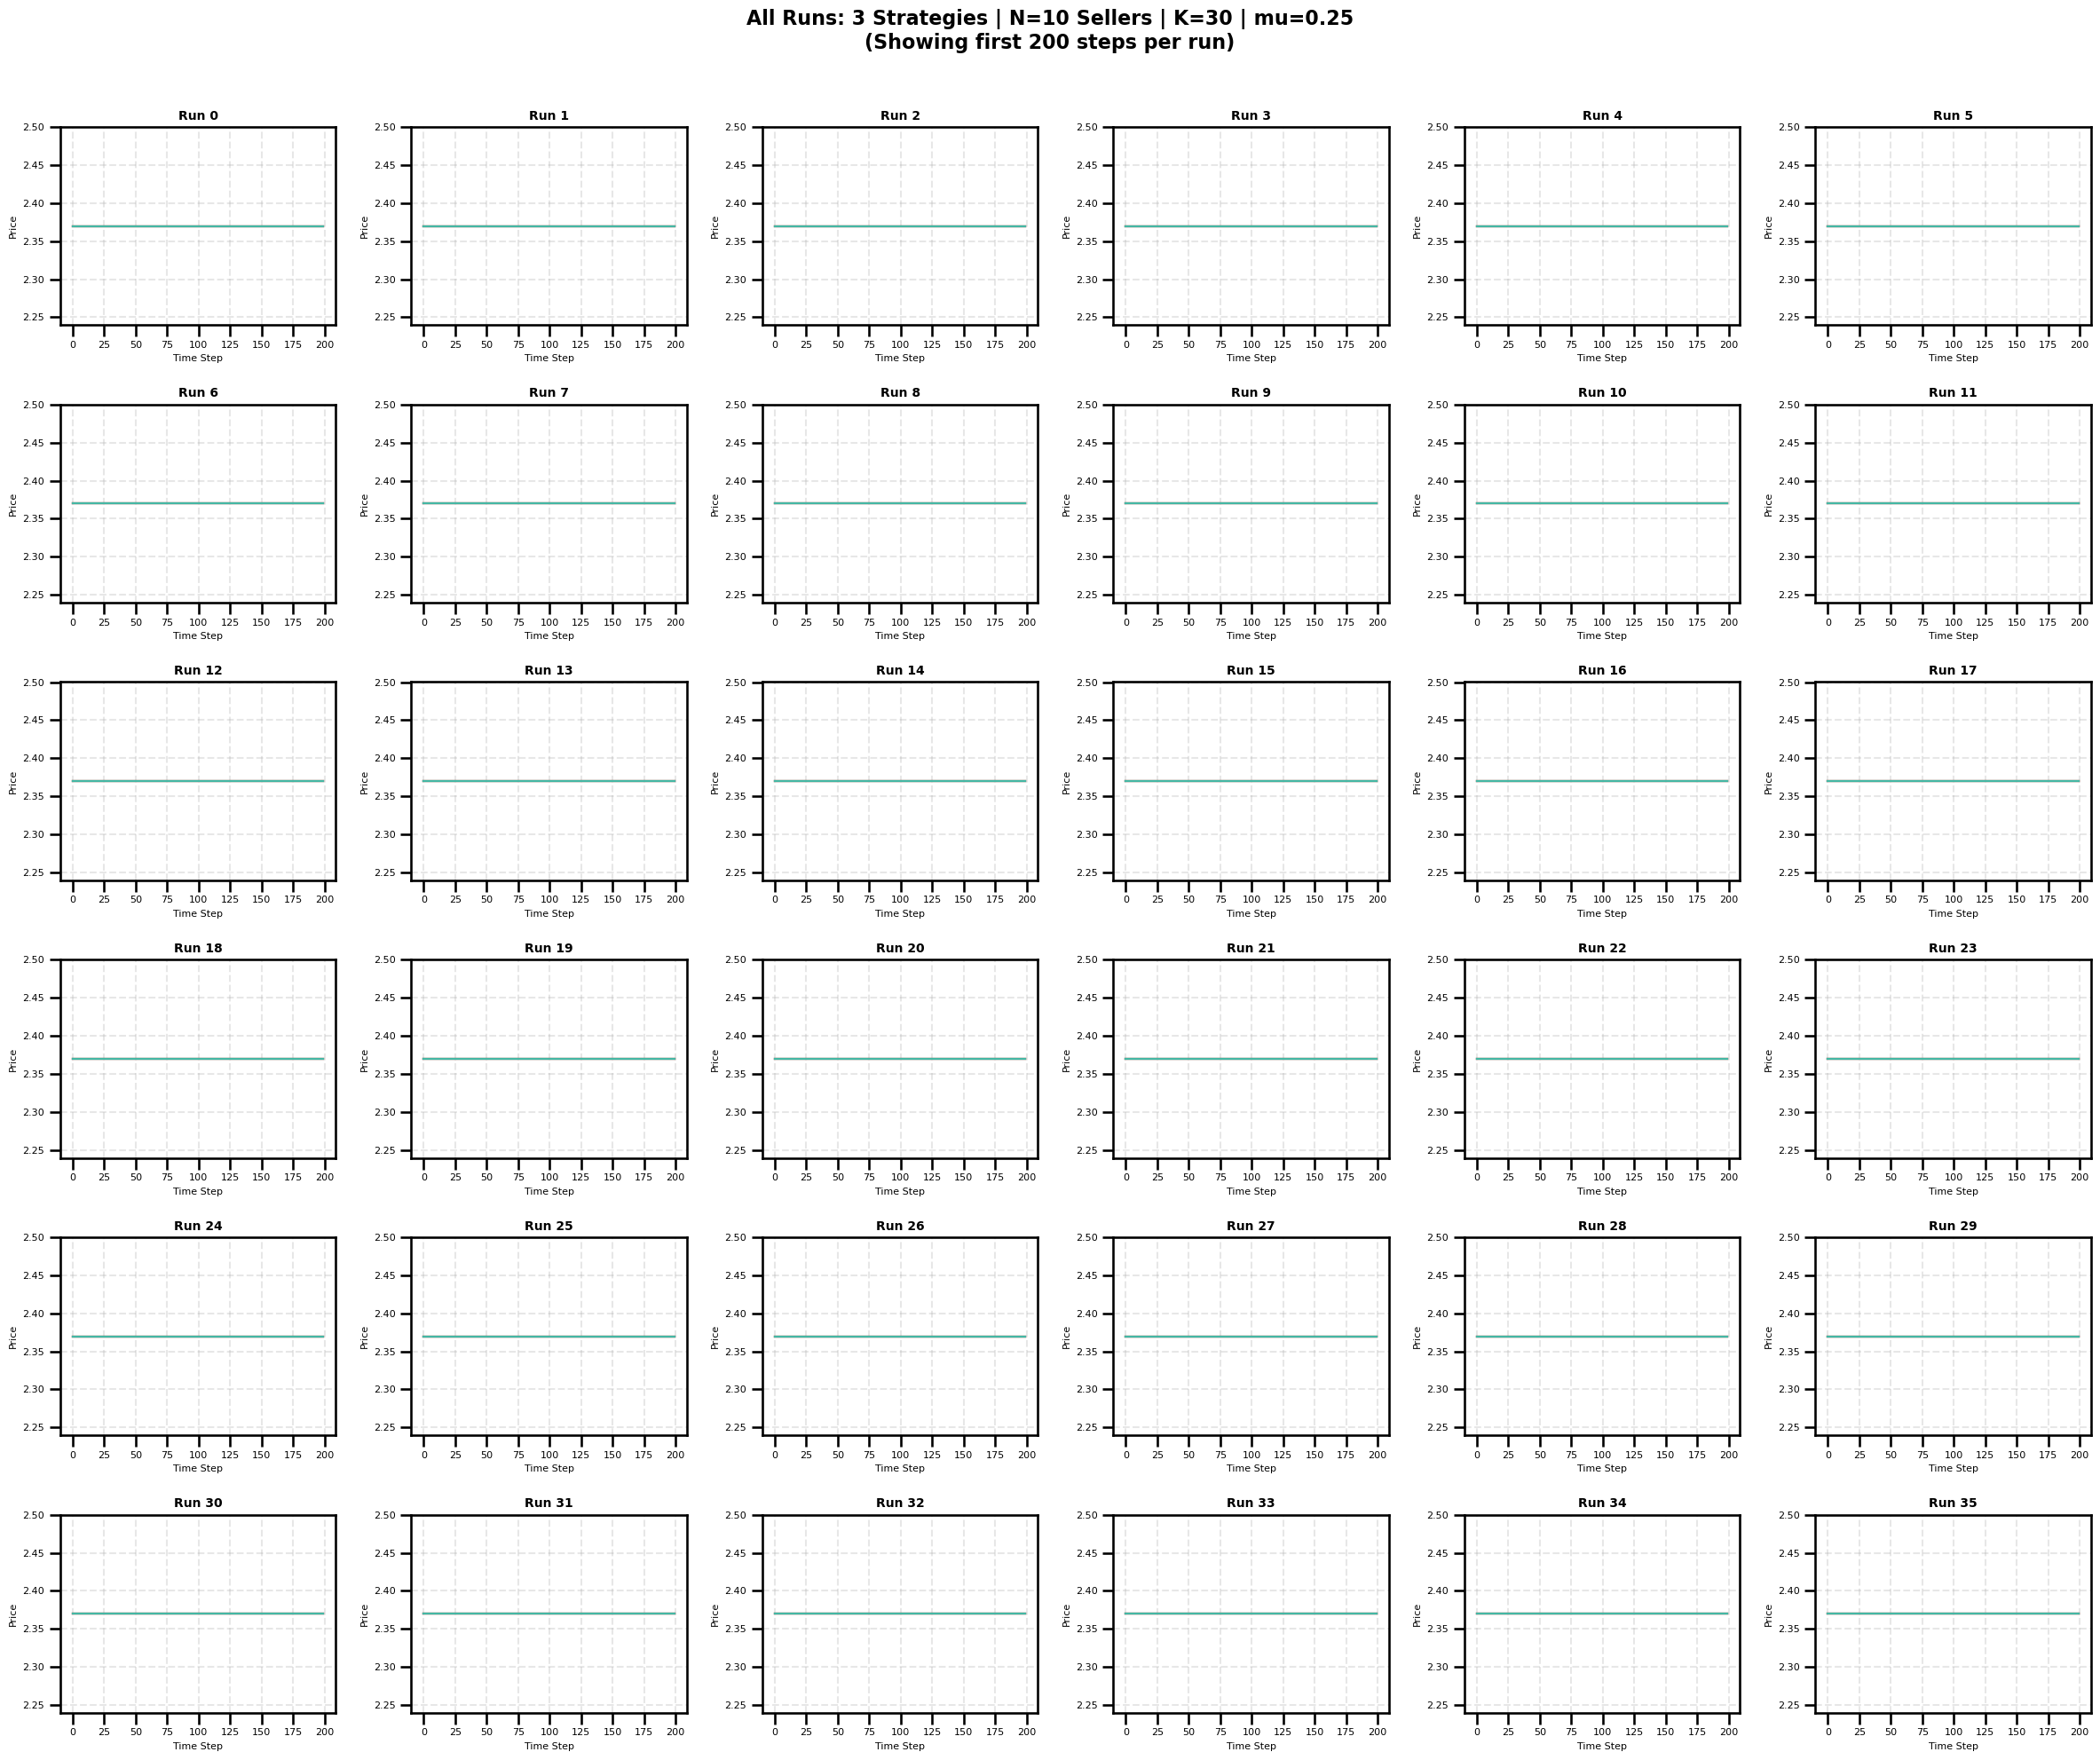

In [50]:
plot_all_runs_grid(strats=3, N=10, k=30, mu=0.25, max_steps=200)

Found 100 runs in scan_4strats_mu0.1_k30/N_10


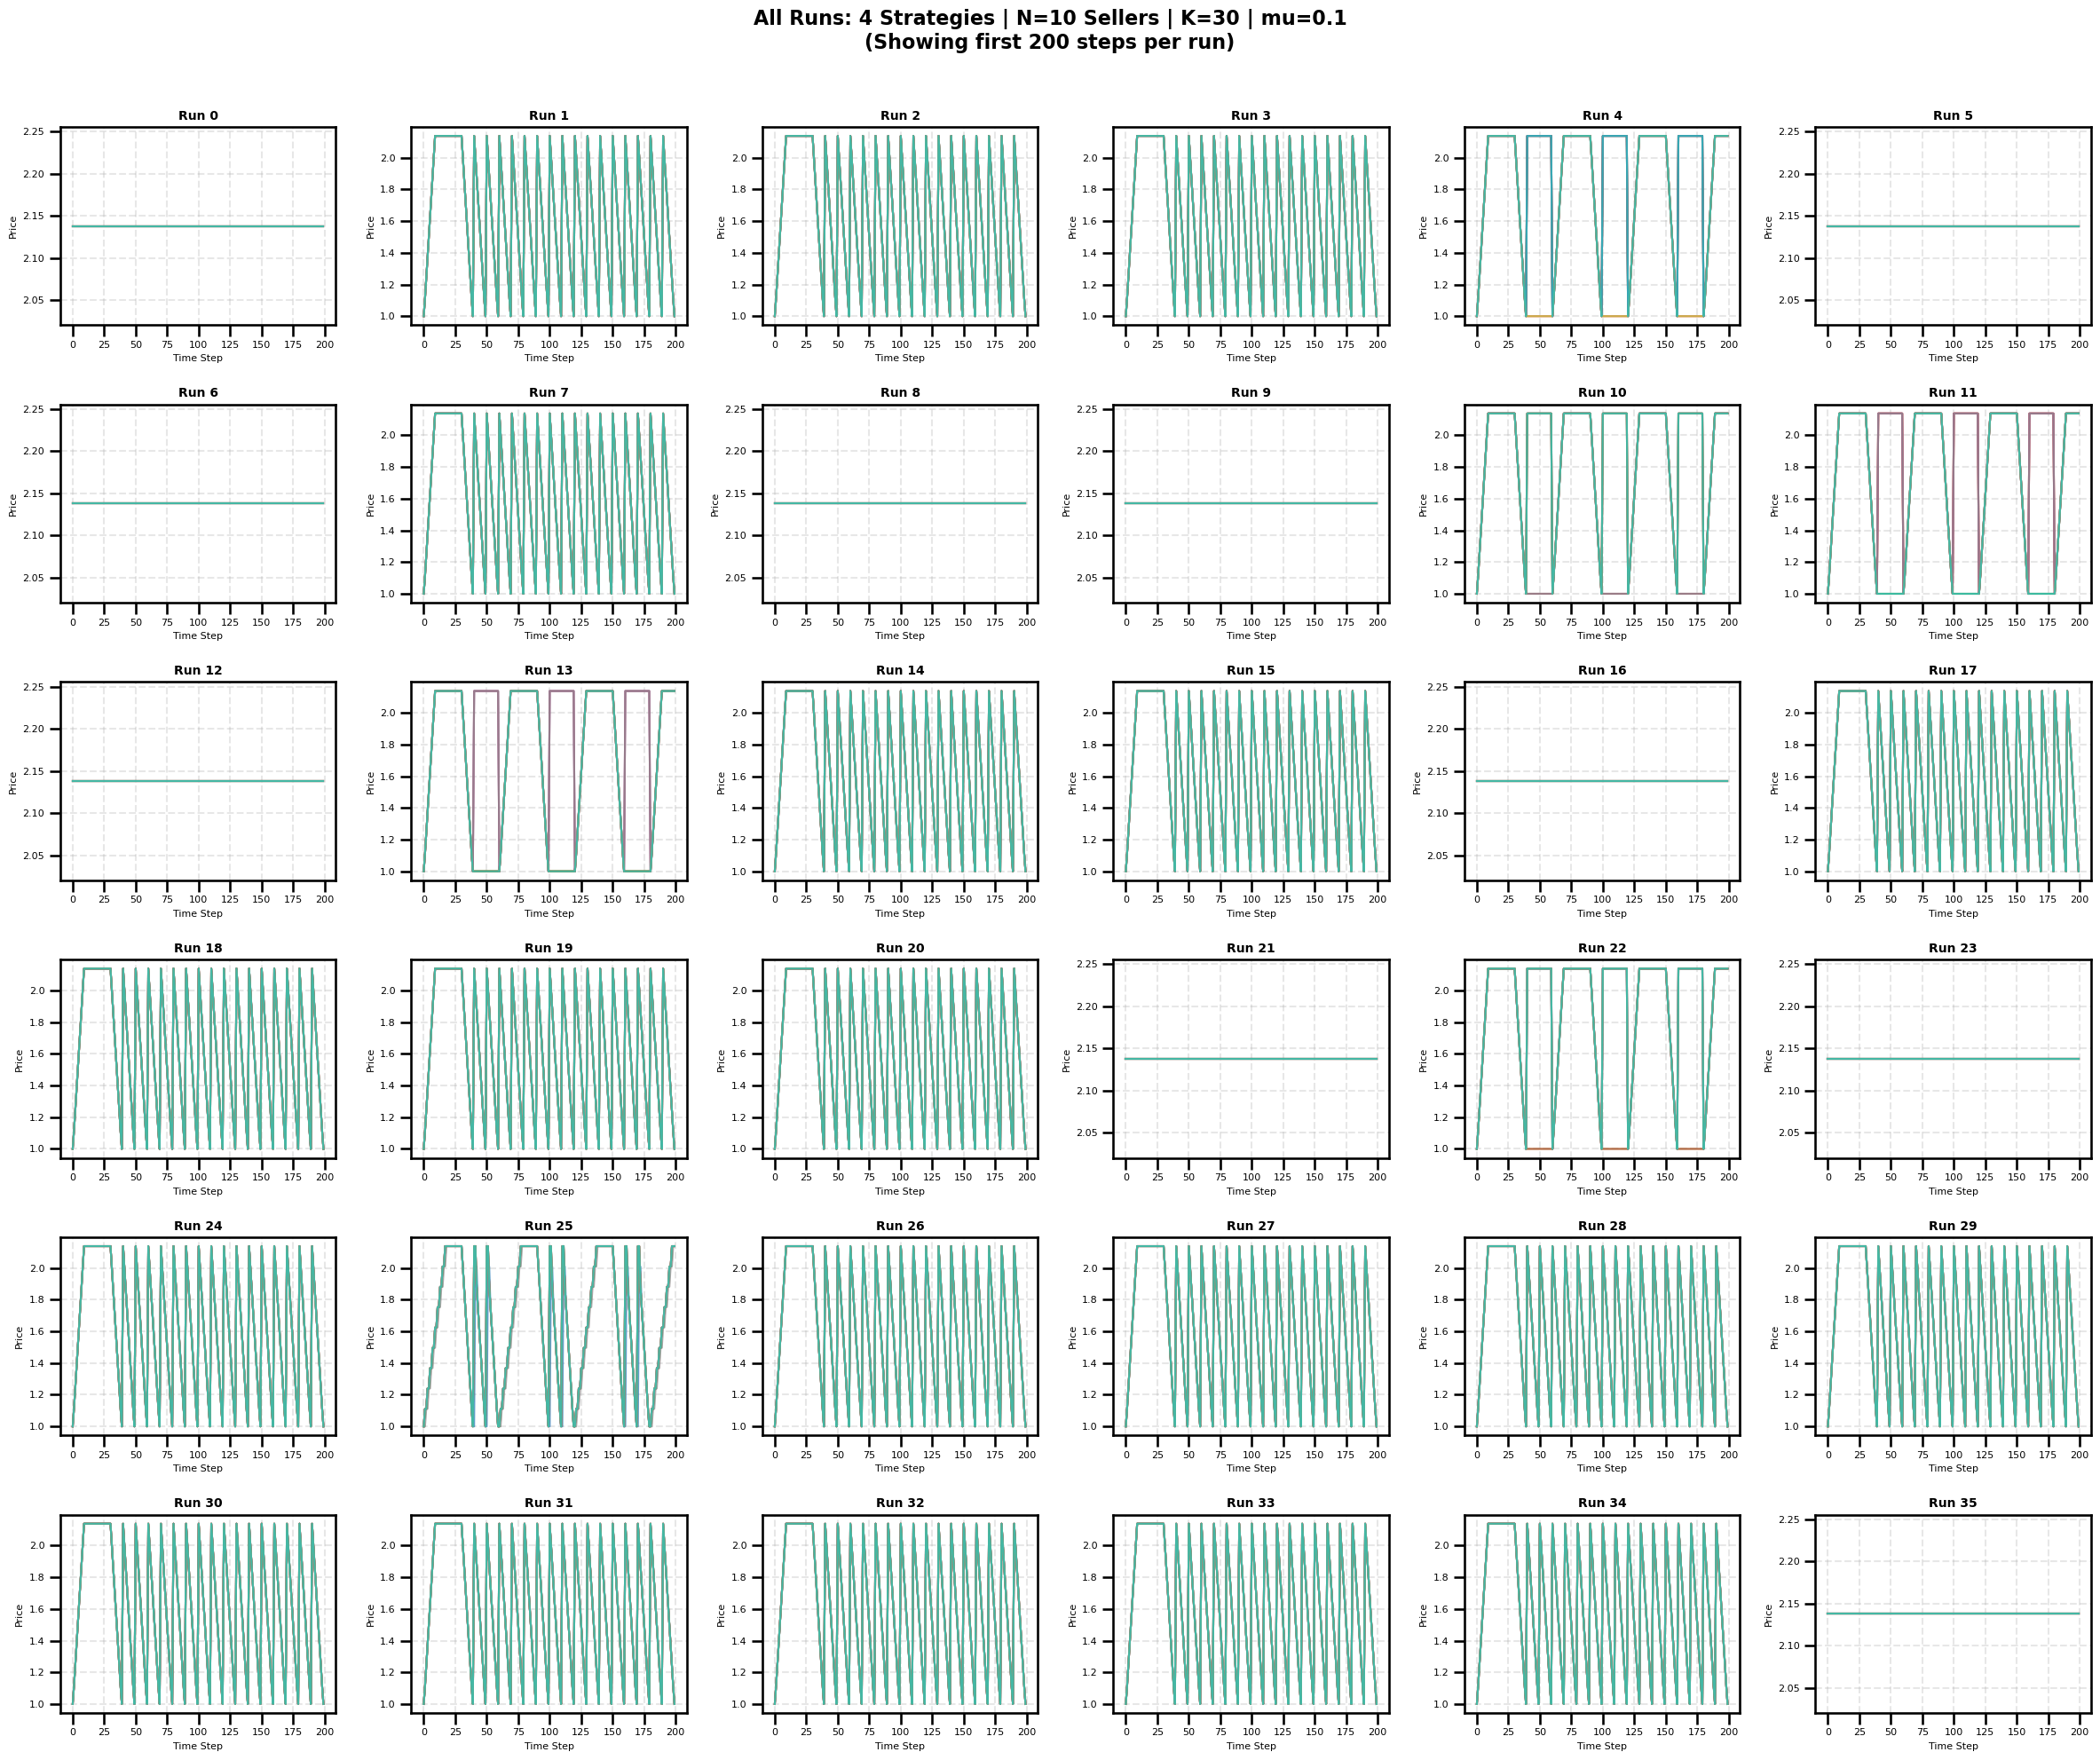

In [51]:
plot_all_runs_grid(strats=4, N=10, k=30, mu=0.1, max_steps=200)

Found 100 runs in scan_3strats_mu0.04_k30/N_10


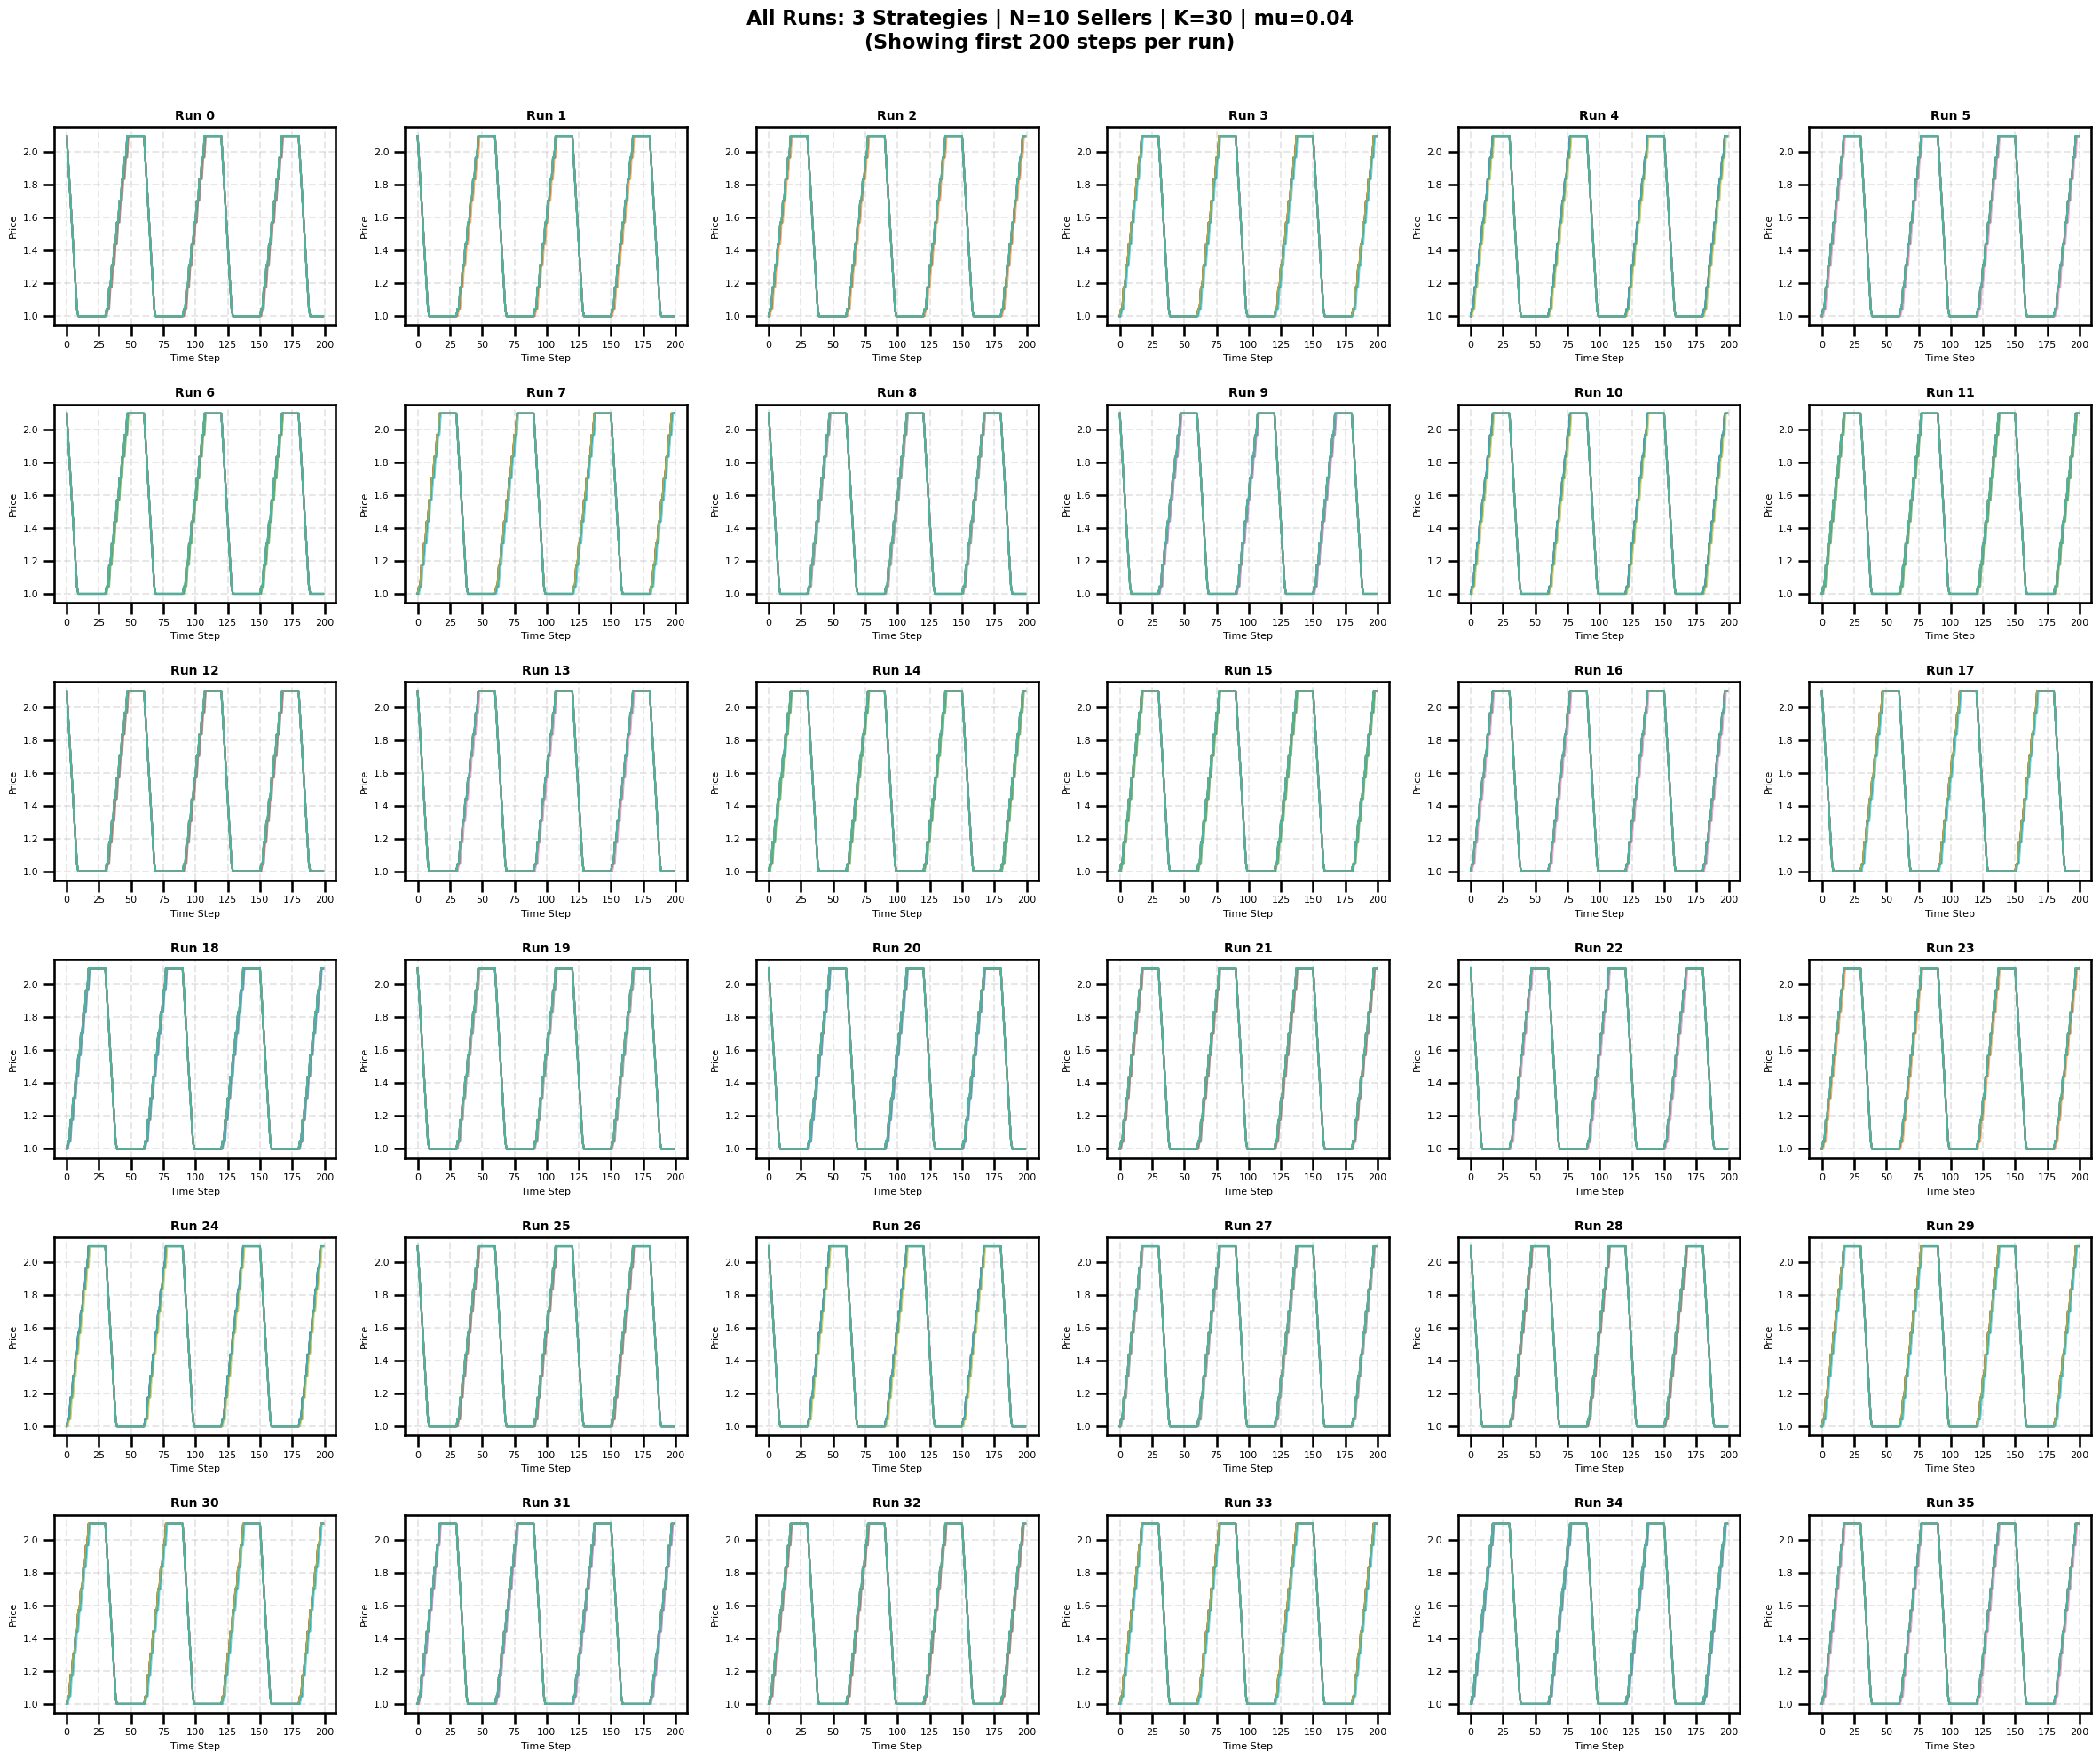

In [52]:
plot_all_runs_grid(strats=3, N=10, k=30, mu=0.04, max_steps=200)

Found 100 runs in scan_4strats_mu0.25_k30/N_10


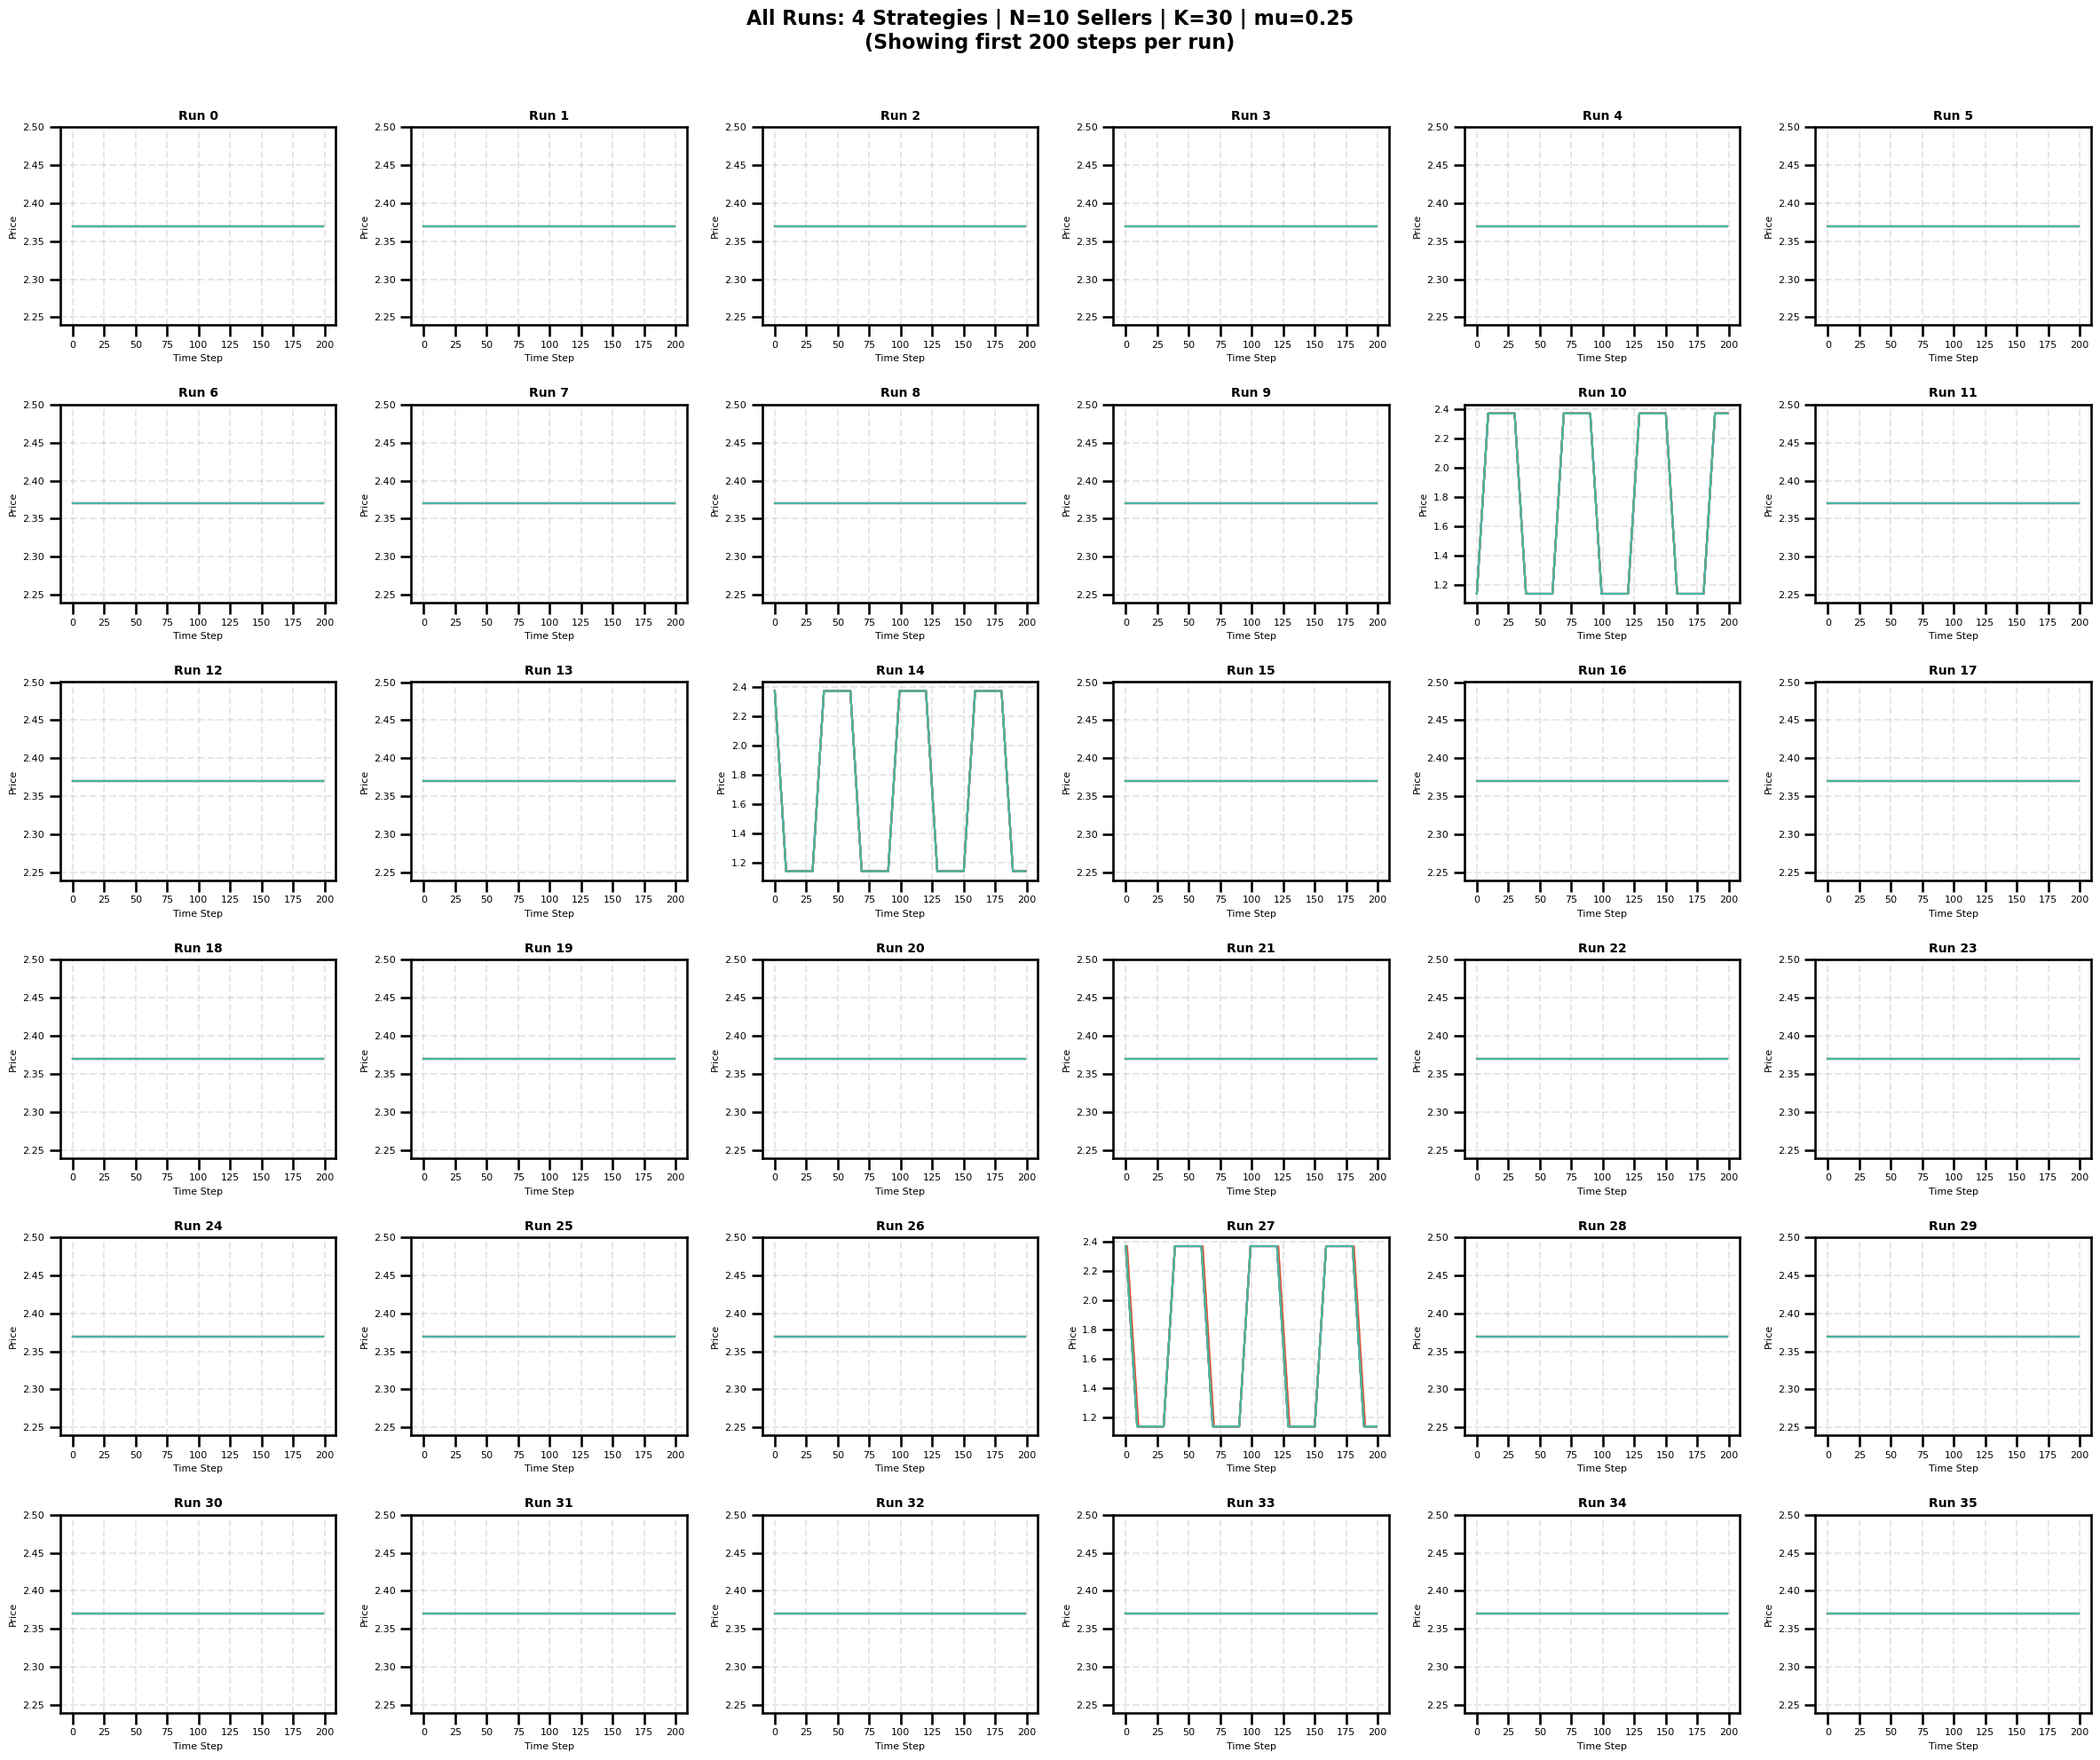

In [53]:
plot_all_runs_grid(strats=4, N=10, k=30, mu=0.25, max_steps=200)

Found 100 runs in scan_4strats_mu0.04_k40/N_10


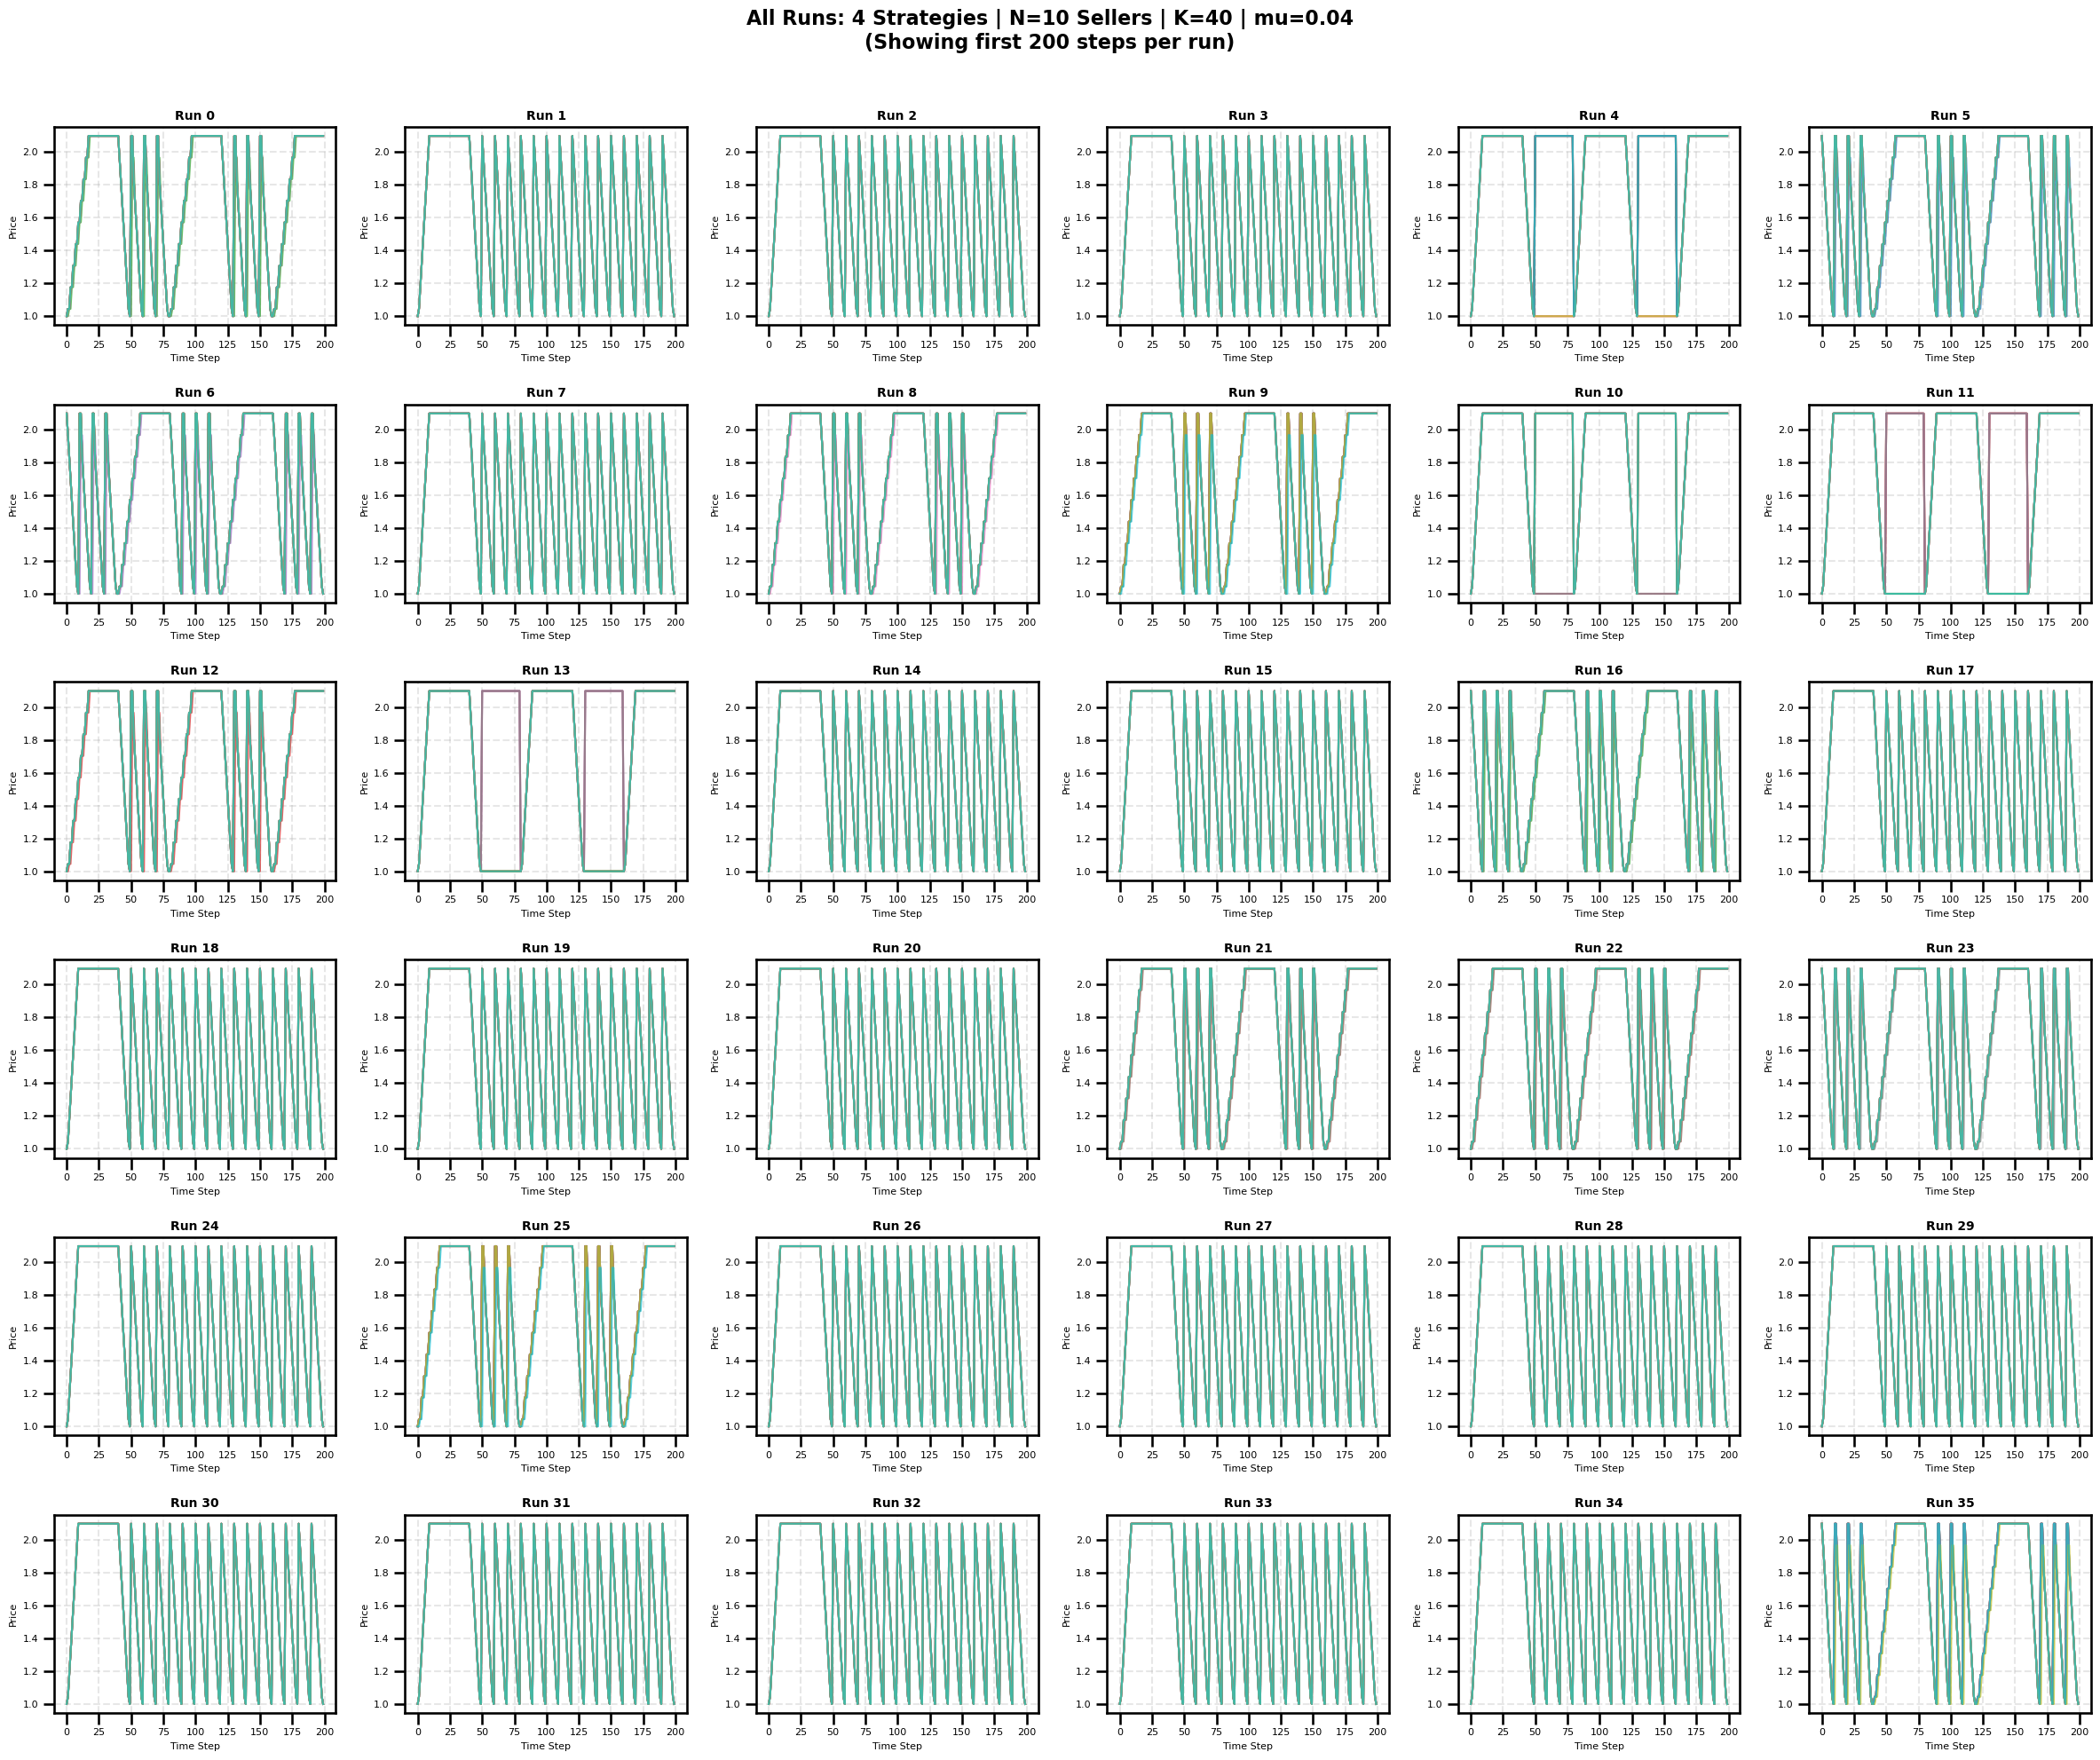

In [54]:
plot_all_runs_grid(strats=4, N=10, k=40, mu=0.04, max_steps=200)

Found 100 runs in scan_4strats_mu0.04_k40/N_10


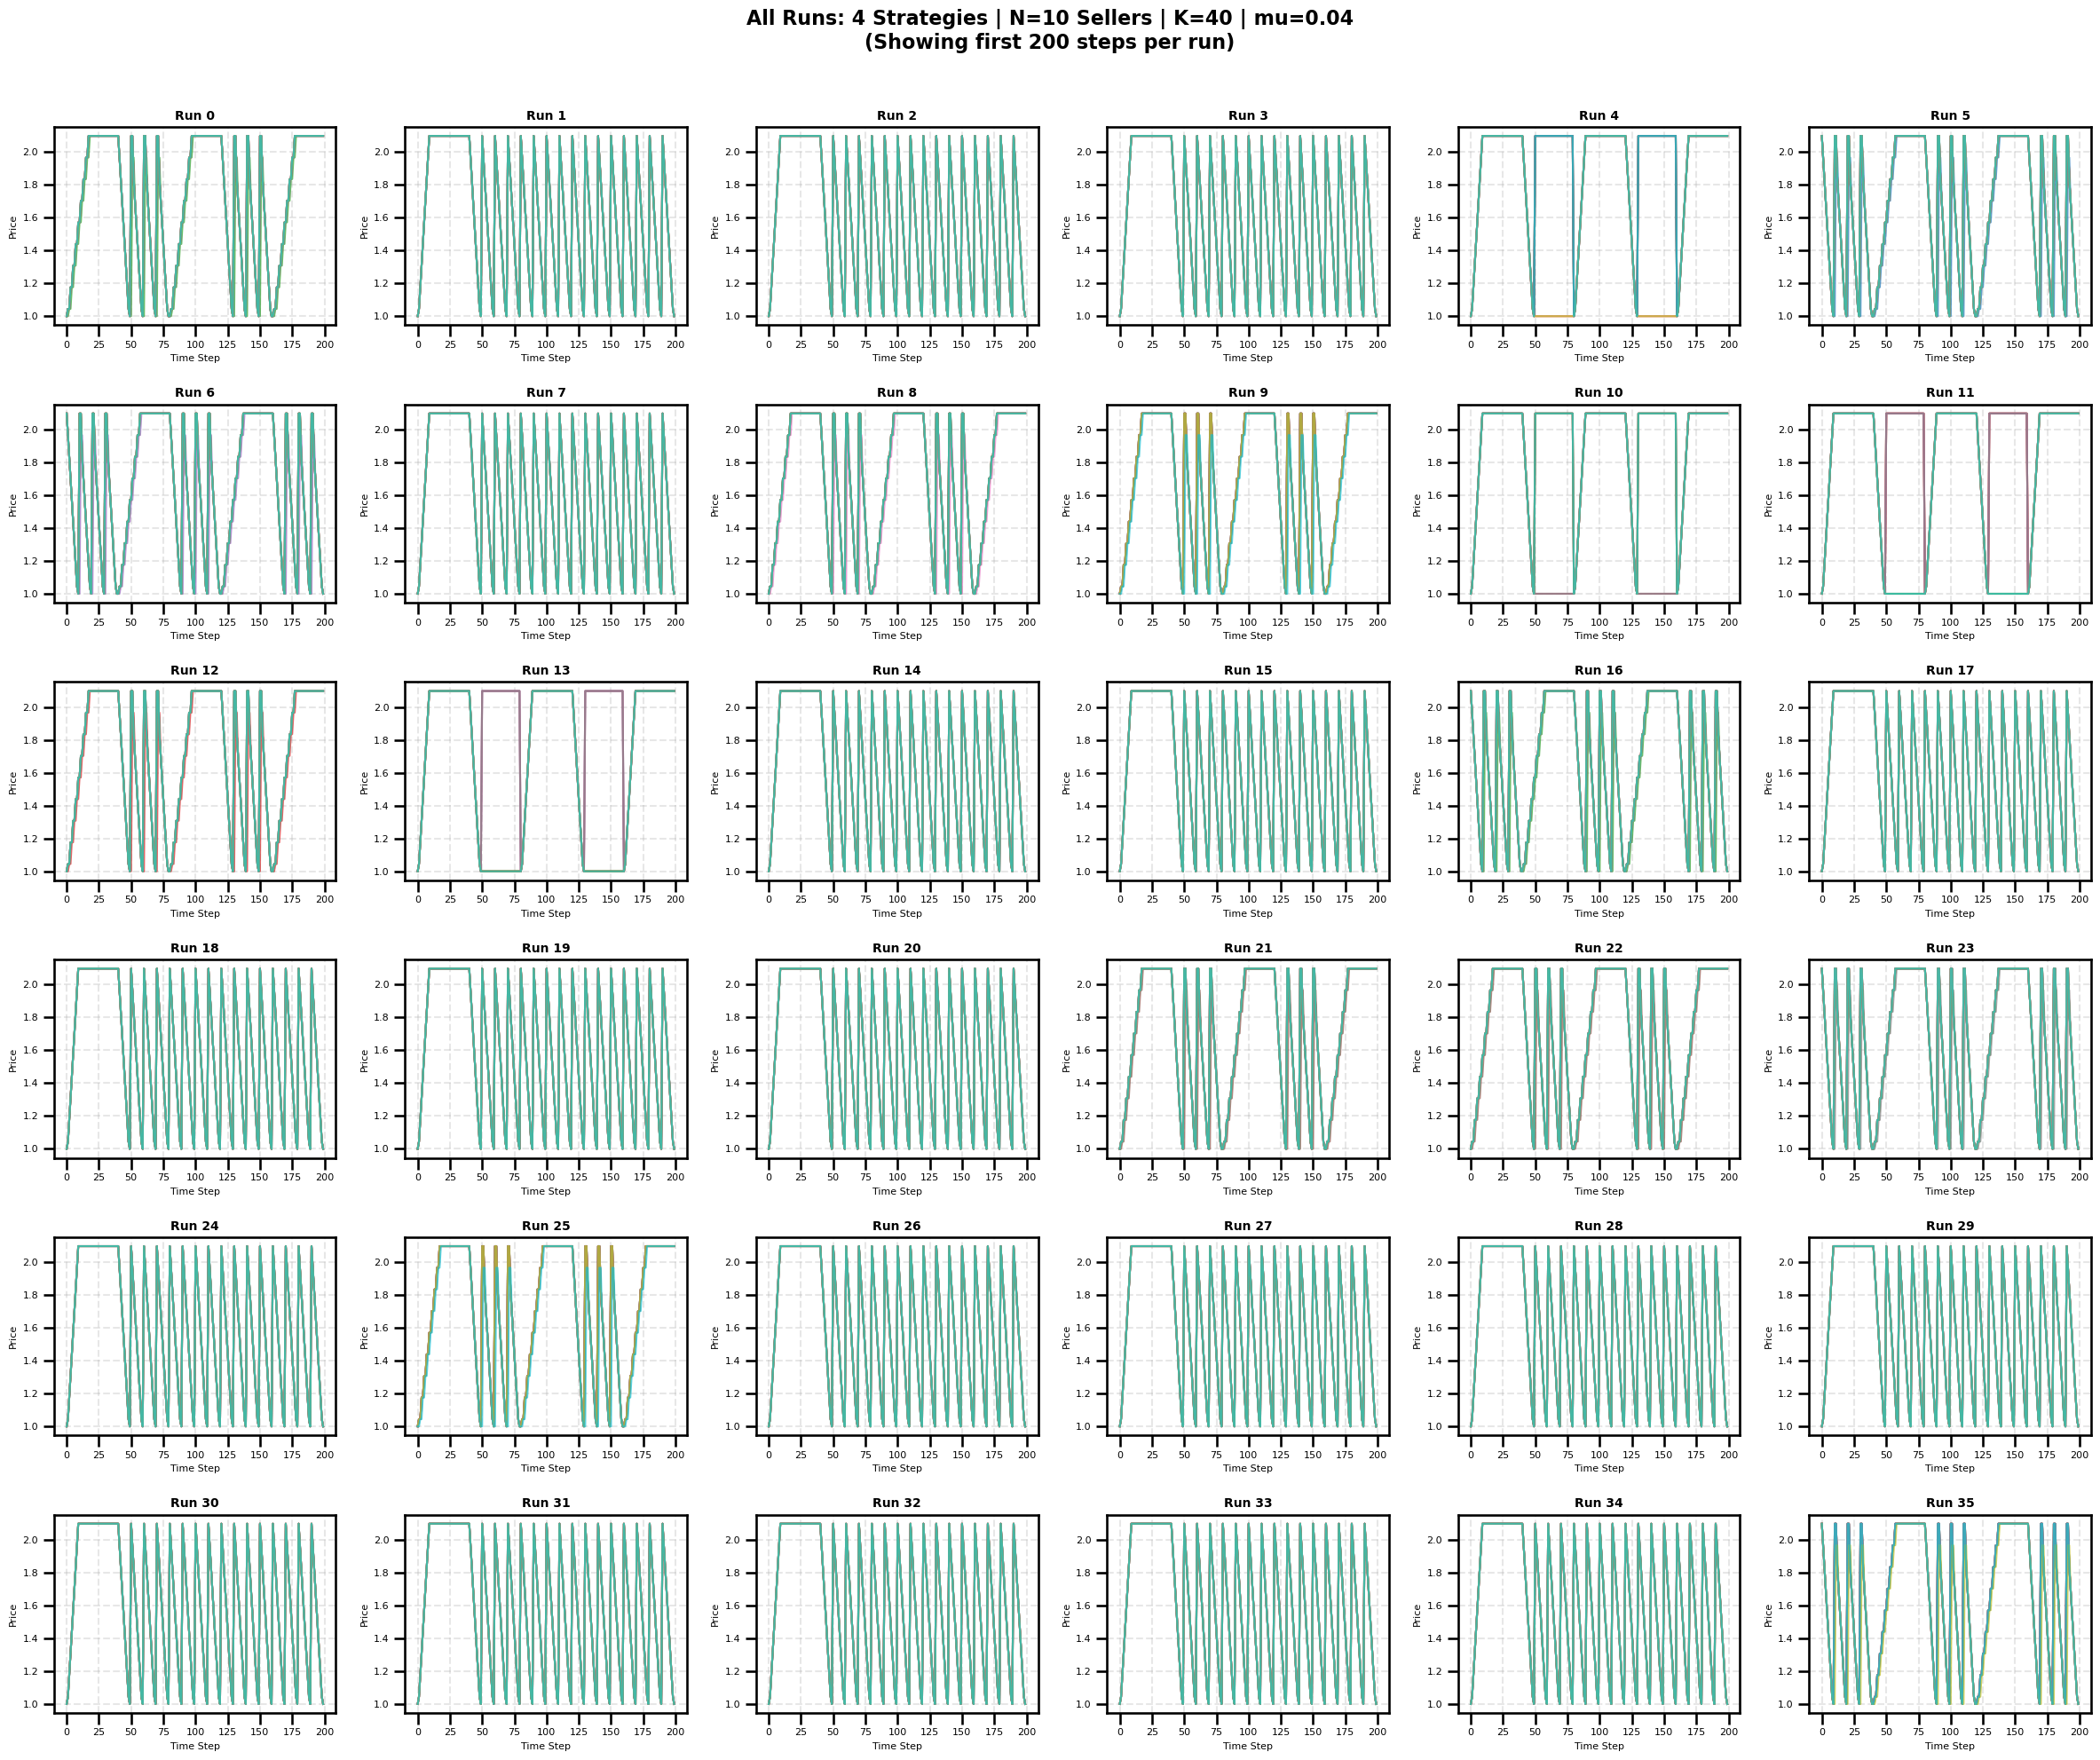

In [55]:
plot_all_runs_grid(strats=4, N=10, k=40, mu=0.04, max_steps=200)

## Interactive: Choose Your Own Configuration

Modify the parameters below to explore different configurations:

In [56]:
# === CUSTOMIZE HERE ===
strats = 3      # 3 or 4
N = 3           # Number of sellers
k = 25          # K parameter
mu = 0.01       # competitiveness
max_steps = 500 # Number of steps to show

plot_all_runs_grid(strats=strats, N=N, k=k, mu=mu, max_steps=max_steps)

No experiment found for: 3strats, mu=0.01, k=25
No data to plot.
